In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings
from collections import Counter
import holidays
warnings.filterwarnings('ignore')
import folium
import geopandas as gpd

In [2]:
# 모든 컬럼 이름을 다 보여주기
pd.set_option('display.max_columns', None)

# 컬럼 하나당 표시할 최대 문자열 길이 제한 없애기
pd.set_option('display.max_colwidth', None)

# 콘솔 폭에 맞춰 자동 줄바꿈 없이 쭉 출력하기
pd.set_option('display.expand_frame_repr', False)

# 전역 출력 포맷 설정: 소수점 2자리 일반 실수 표기
pd.set_option('display.float_format', '{:.7f}'.format)

# 지수표기(sci‑notation) 사용 안 함
np.set_printoptions(suppress=True)

# 소수점 자리수 지정 (예: 소수점 이하 2자리)
np.set_printoptions(formatter={'float_kind': '{:.7f}'.format})

np.set_printoptions(threshold=np.inf)

In [3]:
master = pd.read_csv("../Data/한강공원 주차장 정보.csv",encoding='cp949')

In [4]:
master.columns

Index(['지구별', '주차장별', '위치정보(위도)', '위치정보(경도)', '주소', '면수', '장애면수', '정기면수',
       '주중 이용시간 시작', '주중 이용시간 종료', '주말 이용시간 시작', '주말 이용시간 종료', '면제시간', '기본시간',
       '기본요금', '간격시간', '간격요금', '전일요금', '주간요금', '야간요금', '정기금금액', '주차장 운영업체',
       '업체 전화번호', '운영 시작기간', '운영 종료기간'],
      dtype='object')

In [5]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지구별         29 non-null     object 
 1   주차장별        29 non-null     object 
 2   위치정보(위도)    29 non-null     float64
 3   위치정보(경도)    29 non-null     float64
 4   주소          29 non-null     object 
 5   면수          29 non-null     int64  
 6   장애면수        29 non-null     int64  
 7   정기면수        29 non-null     int64  
 8   주중 이용시간 시작  29 non-null     object 
 9   주중 이용시간 종료  29 non-null     object 
 10  주말 이용시간 시작  29 non-null     object 
 11  주말 이용시간 종료  29 non-null     object 
 12  면제시간        29 non-null     int64  
 13  기본시간        29 non-null     int64  
 14  기본요금        29 non-null     int64  
 15  간격시간        29 non-null     int64  
 16  간격요금        29 non-null     int64  
 17  전일요금        29 non-null     int64  
 18  주간요금        29 non-null     int64  
 19  야간요금        29 non-null     int

In [6]:
master.head()

,지구별,주차장별,위치정보(위도),위치정보(경도),주소,면수,장애면수,정기면수,주중 이용시간 시작,주중 이용시간 종료,주말 이용시간 시작,주말 이용시간 종료,면제시간,기본시간,기본요금,간격시간,간격요금,전일요금,주간요금,야간요금,정기금금액,주차장 운영업체,업체 전화번호,운영 시작기간,운영 종료기간
0,강서,강서1주차장,37.5857090,126.8182790,서울강서구방화동61(방화동),52,0,0,06:00,24:00,06:00,24:00,10,30,1000,10,200,10000,0,0,50000,공우이엔씨(주)_양화_강서,02-2068-9617,2023-12-01 00:00:00.0,2025-11-30 00:00:00.0
1,광나루,"광나루1,2주차장",37.5538850,127.1231600,서울강동구암사동613-11,160,0,0,06:00,24:00,06:00,24:00,0,0,0,10,200,10000,0,0,50000,공우이엔씨(주)_잠실_광나루,02-3431-3774,2023-12-01 00:00:00.0,2025-11-30 00:00:00.0
2,광나루,광나루3주차장,37.5430780,127.1177750,서울강동구풍납동49-2,183,0,0,06:00,24:00,06:00,24:00,10,30,1000,10,200,10000,0,0,50000,공우이엔씨(주)_잠실_광나루,02-3431-3774,2023-12-01 00:00:00.0,2025-11-30 00:00:00.0
3,난지,"난지1,2,3,4주차장",37.5698219,126.8736403,서울마포구상암동487-370,618,0,0,06:00,24:00,06:00,24:00,0,0,0,10,200,10000,0,0,50000,(주)현암파킹_망원_난지,"(주간) 010-2821-9227 , (야간) 070-7076-0132",2025-02-01 00:00:00.0,2027-01-31 00:00:00.0
4,뚝섬,뚝섬1주차장,37.5276908,127.0781632,서울광진구자양동409(자양동),64,0,0,06:00,24:00,06:00,24:00,10,30,1000,10,200,10000,0,0,50000,공우이엔씨(주)_뚝섬,02-455-7279,2024-12-01 00:00:00.0,2026-11-30 00:00:00.0


In [7]:
parking = pd.read_csv("../Data/한강공원 주차장 일별 이용 현황.csv",encoding="cp949")

In [8]:
parking.head()

,지구별,주차장명,주차대수,이용시간,날짜
0,PLT-008,여의도5주차장,214,13825,2025/08/10
1,PLT-003,망원1주차장,625,68058,2025/08/10
2,PLT-007,양화1주차장,381,30597,2025/08/10
3,PLT-011,"잠실2,3주차장",1296,169461,2025/08/10
4,PLT-005,뚝섬4주차장,1053,113970,2025/08/10


## 잠원 Here We GO

In [9]:
잠원_parking = parking[parking['주차장명'].str.contains("잠원")]

In [10]:
잠원_parking['평균이용시간']=잠원_parking['이용시간'] / 잠원_parking['주차대수']

In [11]:
잠원_parking['날짜'] = pd.to_datetime(잠원_parking['날짜'], format='%Y/%m/%d')

In [12]:
잠원_parking['년도'] = 잠원_parking['날짜'].dt.year
잠원_parking['월'] = 잠원_parking['날짜'].dt.month
잠원_parking['일'] = 잠원_parking['날짜'].dt.day

In [13]:
잠원_parking.head()

,지구별,주차장명,주차대수,이용시간,날짜,평균이용시간,년도,월,일
17,PLT-010,잠원1주차장,1087,72215,2025-08-10,66.4351426,2025,8,10
25,PLT-010,잠원2-6주차장,3012,396418,2025-08-10,131.6128818,2025,8,10
28,PLT-010,잠원2-6주차장,2977,335264,2025-08-09,112.6180719,2025,8,9
51,PLT-010,잠원1주차장,1075,74136,2025-08-09,68.9637209,2025,8,9
57,PLT-010,잠원2-6주차장,2449,305089,2025-08-08,124.5769702,2025,8,8


In [14]:
# 2. 날짜별 개수 세기
counts = 잠원_parking['날짜'].value_counts()

# 3. 개수가 정확히 2인 날짜만 필터
target_dates = counts[counts == 2].index
filtered_잠원_parking = 잠원_parking[잠원_parking['날짜'].isin(target_dates)]

In [15]:
filtered_잠원_parking.head()

,지구별,주차장명,주차대수,이용시간,날짜,평균이용시간,년도,월,일
17,PLT-010,잠원1주차장,1087,72215,2025-08-10,66.4351426,2025,8,10
25,PLT-010,잠원2-6주차장,3012,396418,2025-08-10,131.6128818,2025,8,10
28,PLT-010,잠원2-6주차장,2977,335264,2025-08-09,112.6180719,2025,8,9
51,PLT-010,잠원1주차장,1075,74136,2025-08-09,68.9637209,2025,8,9
57,PLT-010,잠원2-6주차장,2449,305089,2025-08-08,124.5769702,2025,8,8


In [16]:
parking = filtered_잠원_parking[(filtered_잠원_parking['년도'] == 2024) | (filtered_잠원_parking['년도'] == 2023)].reset_index(drop=True)

In [17]:
parking.head()

,지구별,주차장명,주차대수,이용시간,날짜,평균이용시간,년도,월,일
0,PLT-010,잠원2-6주차장,2350,227695,2024-12-31,96.8914894,2024,12,31
1,PLT-010,잠원1주차장,290,20877,2024-12-31,71.9896552,2024,12,31
2,PLT-010,잠원2-6주차장,2312,226340,2024-12-30,97.8979239,2024,12,30
3,PLT-010,잠원1주차장,278,23471,2024-12-30,84.4280576,2024,12,30
4,PLT-010,잠원2-6주차장,2324,222207,2024-12-29,95.6140275,2024,12,29


In [18]:
weather_2023 = pd.read_csv("../Data/2023_날씨.csv",encoding='cp949')

In [19]:
weather_2024 = pd.read_csv("../Data/2024_날씨.csv",encoding='cp949')

In [20]:
weather = pd.concat([weather_2023,weather_2024])

In [21]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17496 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   지점            17496 non-null  int64  
 1   지점명           17496 non-null  object 
 2   일시            17496 non-null  object 
 3   기온(°C)        17496 non-null  float64
 4   기온 QC플래그      0 non-null      float64
 5   강수량(mm)       2038 non-null   float64
 6   풍속(m/s)       17428 non-null  float64
 7   풍향(16방위)      17428 non-null  float64
 8   습도(%)         17496 non-null  int64  
 9   현지기압(hPa)     17496 non-null  float64
 10  해면기압(hPa)     17496 non-null  float64
 11  일조(hr)        9543 non-null   float64
 12  일조 QC플래그      7919 non-null   float64
 13  일사(MJ/m2)     9544 non-null   float64
 14  일사 QC플래그      7919 non-null   float64
 15  적설(cm)        655 non-null    float64
 16  3시간신적설(cm)    64 non-null     float64
 17  전운량(10분위)     17496 non-null  int64  
 18  중하층운량(10분위)   17496 non-null  in

In [22]:
weather = weather[['일시','기온(°C)','습도(%)','풍속(m/s)']]

### 불쾌지수 공식:
DI = 0.81·T + 0.01·RH·(0.99·T − 14.3) + 46.3

In [23]:
weather['불쾌지수'] = 0.81 * weather['기온(°C)'] + 0.01 * weather['습도(%)'] * (0.99 * weather['기온(°C)'] - 14.3) + 46.3

In [24]:
weather.drop(['기온(°C)','습도(%)'], axis='columns',inplace=True)

In [25]:
weather.head()

,일시,풍속(m/s),불쾌지수
0,2023-01-01 01:00,1.9000000,38.4163500
1,2023-01-01 02:00,1.9000000,38.2882000
2,2023-01-01 03:00,1.6000000,38.1861600
3,2023-01-01 04:00,1.4000000,38.0319000
4,2023-01-01 05:00,2.4000000,38.5730400


In [26]:
weather['일시'] = pd.to_datetime(weather['일시'], errors='coerce')

In [27]:
weather.head()

,일시,풍속(m/s),불쾌지수
0,2023-01-01 01:00:00,1.9000000,38.4163500
1,2023-01-01 02:00:00,1.9000000,38.2882000
2,2023-01-01 03:00:00,1.6000000,38.1861600
3,2023-01-01 04:00:00,1.4000000,38.0319000
4,2023-01-01 05:00:00,2.4000000,38.5730400


In [28]:
weather['날짜'] = pd.to_datetime(weather['일시'], errors='coerce').dt.date   
weather['시간'] = pd.to_datetime(weather['일시'], errors='coerce').dt.time   

In [29]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17496 entries, 0 to 8759
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   일시       17496 non-null  datetime64[ns]
 1   풍속(m/s)  17428 non-null  float64       
 2   불쾌지수     17496 non-null  float64       
 3   날짜       17496 non-null  object        
 4   시간       17496 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 820.1+ KB


In [30]:
weather['시간_시'] = weather['시간'].astype(str).str.extract(r'^(\d{1,2}):')[0].astype('Int64')

In [32]:
weather.drop(['일시'],axis='columns',inplace=True)

In [ ]:
# weather.to_csv('../Data/2023-2024날씨_전처리_완.csv',index=False)

In [33]:
subway_2023 = pd.read_csv("../Data/2023_지하철.csv")
subway_2024 = pd.read_csv("../Data/2024_지하철.csv")

In [34]:
subway_2023.head()

,수송일자,역명,승하차구분,시간대,인원수
0,2023-01-01,압구정,승차,6,111
1,2023-01-01,압구정,하차,6,35
2,2023-01-01,신사,승차,6,327
3,2023-01-01,신사,하차,6,30
4,2023-01-01,잠원,승차,6,18


In [35]:
subway_2023['인원수'].unique()

array([ 111,   35,  327,   30,   18,   11,   90,   81,   97,   73,   44,
         29,   87,   95,  116,   62,   38,  102,  101,  112,   65,   45,
         33,  107,   93,  133,   37,   92,   75,  125,   68,   46,   32,
        108,   56,  181,   24,   34,   71,  159,   19,  103,  109,   39,
         43,   84,   67,   41,   98,   96,  124,   74,   80,   40,   79,
        118,   66,   28,   49,  149,   36,   31,   85,  183,   26,   17,
          9,  100,   60,   70,  110,  114,  127,   47,  105,   72,  209,
         25,   15,   63,  104,   10,   21,    6,   61,   86,   94,   83,
         50,  192,   77,  165,   14,   82,   51,   91,  119,   78,  117,
         89,  142,  148,  106,   42,  115,   99,  130,  123,   76,   53,
        191,  144,   23,  132,   48,  134,  194,   54,  187,    8,  128,
         58,  145,  156,   27,   16,   12,   64,   88,  174,   13,   57,
        172,   55,  185,   22,  120,   52,  137,  113,  121,  175,  179,
        182,  171,  170,   69,  138,  151,  232,  1

In [36]:
subway_2023['수송일자'] = pd.to_datetime(subway_2023['수송일자'], format='%Y-%m-%d')

In [37]:
subway_2023['해당_월'] = subway_2023['수송일자'].dt.month

In [38]:
subway_2023['해당_일'] = subway_2023['수송일자'].dt.day

In [41]:
subway_2024['수송일자'] = pd.to_datetime(subway_2024['수송일자'], format='%Y-%m-%d')
subway_2024['해당_월'] = subway_2024['수송일자'].dt.month
subway_2024['해당_일'] = subway_2024['수송일자'].dt.day

In [39]:
kr_holidays = holidays.KR(years=2023)

subway_2023['공휴일여부'] = np.where(
    subway_2023['수송일자'].isin(kr_holidays),
    "공휴일",
    np.where(
        subway_2023['수송일자'].dt.weekday >= 5,
        '주말',
        '평일'
    )
)

subway_2023['공휴일여부'] = subway_2023['공휴일여부'].apply(
    lambda x: '쉬는날' if x in ['주말', '공휴일'] else '평일'
)


In [42]:
kr_holidays = holidays.KR(years=2024)

subway_2024['공휴일여부'] = np.where(
    subway_2024['수송일자'].isin(kr_holidays),
    "공휴일",
    np.where(
        subway_2024['수송일자'].dt.weekday >= 5,
        '주말',
        '평일'
    )
)

subway_2024['공휴일여부'] = subway_2024['공휴일여부'].apply(
    lambda x: '쉬는날' if x in ['주말', '공휴일'] else '평일'
)


In [43]:
subway_2023.head()

,수송일자,역명,승하차구분,시간대,인원수,해당_월,해당_일,공휴일여부
0,2023-01-01,압구정,승차,6,111,1,1,쉬는날
1,2023-01-01,압구정,하차,6,35,1,1,쉬는날
2,2023-01-01,신사,승차,6,327,1,1,쉬는날
3,2023-01-01,신사,하차,6,30,1,1,쉬는날
4,2023-01-01,잠원,승차,6,18,1,1,쉬는날


In [44]:
subway_2023_holi = subway_2023[subway_2023.공휴일여부 == '쉬는날']
subway_2023_week = subway_2023[subway_2023.공휴일여부 == '평일']

In [45]:
subway_2024_holi = subway_2024[subway_2024.공휴일여부 == '쉬는날']
subway_2024_week = subway_2024[subway_2024.공휴일여부 == '평일']

In [46]:
subway_2023_holi.head()

,수송일자,역명,승하차구분,시간대,인원수,해당_월,해당_일,공휴일여부
0,2023-01-01,압구정,승차,6,111,1,1,쉬는날
1,2023-01-01,압구정,하차,6,35,1,1,쉬는날
2,2023-01-01,신사,승차,6,327,1,1,쉬는날
3,2023-01-01,신사,하차,6,30,1,1,쉬는날
4,2023-01-01,잠원,승차,6,18,1,1,쉬는날


In [47]:
pivot_2023_holi = subway_2023_holi.pivot_table(
    ['인원수'],
    index='해당_월',
    aggfunc='sum'
)

In [48]:
pivot_2023_week = subway_2023_week.pivot_table(
    ['인원수'],
    index='해당_월',
    aggfunc='sum'
)

In [49]:
subway_2024['수송일자'] = pd.to_datetime(subway_2024['수송일자'], format='%Y-%m-%d')
subway_2024['해당_월'] = subway_2024['수송일자'].dt.month
pivot_2024 = subway_2024.pivot_table(
    ['인원수'],
    index='해당_월',
    aggfunc='sum'
)

In [50]:
subway = pd.concat([subway_2023,subway_2024])

In [51]:
pivot_2024_holi = subway_2024_holi.pivot_table(
    ['인원수'],
    index='해당_월',
    aggfunc='sum'
)

pivot_2024_week = subway_2024_week.pivot_table(
    ['인원수'],
    index='해당_월',
    aggfunc='sum'
)

In [52]:
subway.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83334 entries, 0 to 41723
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   수송일자    83334 non-null  datetime64[ns]
 1   역명      83334 non-null  object        
 2   승하차구분   83334 non-null  object        
 3   시간대     83334 non-null  int64         
 4   인원수     83334 non-null  int64         
 5   해당_월    83334 non-null  int32         
 6   해당_일    83334 non-null  int32         
 7   공휴일여부   83334 non-null  object        
dtypes: datetime64[ns](1), int32(2), int64(2), object(3)
memory usage: 5.1+ MB


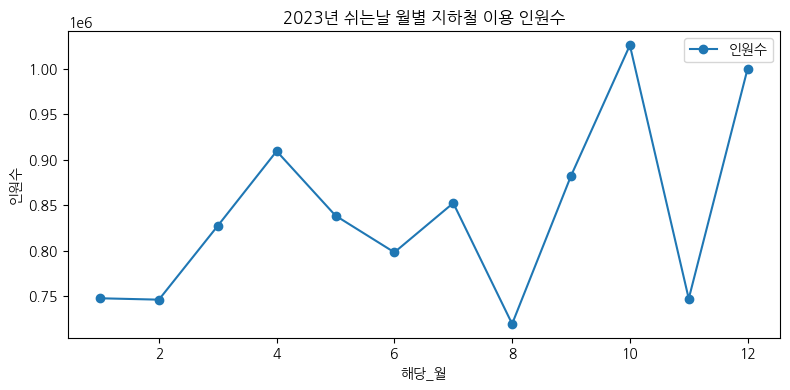

In [53]:
pivot_2023_holi = pivot_2023_holi.sort_index()

ax = pivot_2023_holi.plot(
    y='인원수', kind='line', marker='o', figsize=(8, 4)
)
ax.set_title('2023년 쉬는날 월별 지하철 이용 인원수')
ax.set_xlabel('해당_월')
ax.set_ylabel('인원수')
plt.tight_layout()
plt.show()

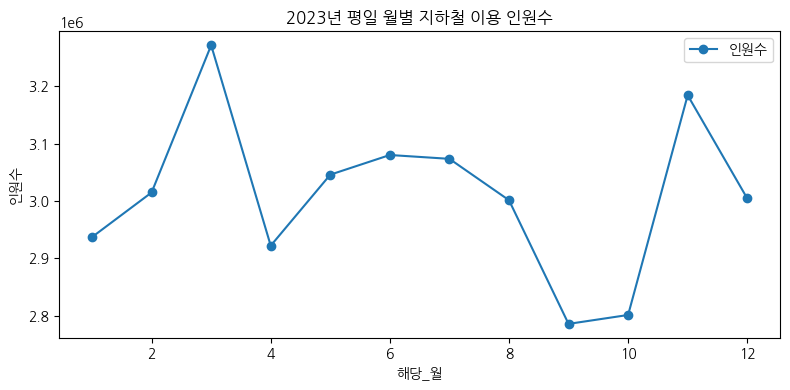

In [54]:
pivot_2023_week = pivot_2023_week.sort_index()

ax = pivot_2023_week.plot(
    y='인원수', kind='line', marker='o', figsize=(8, 4)
)
ax.set_title('2023년 평일 월별 지하철 이용 인원수')
ax.set_xlabel('해당_월')
ax.set_ylabel('인원수')
plt.tight_layout()
plt.show()

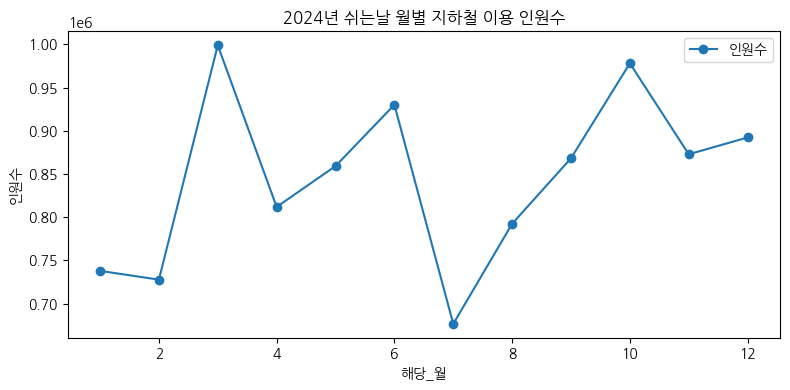

In [55]:
pivot_2024_holi = pivot_2024_holi.sort_index()

ax = pivot_2024_holi.plot(
    y='인원수', kind='line', marker='o', figsize=(8, 4)
)
ax.set_title('2024년 쉬는날 월별 지하철 이용 인원수')
ax.set_xlabel('해당_월')
ax.set_ylabel('인원수')
plt.tight_layout()
plt.show()

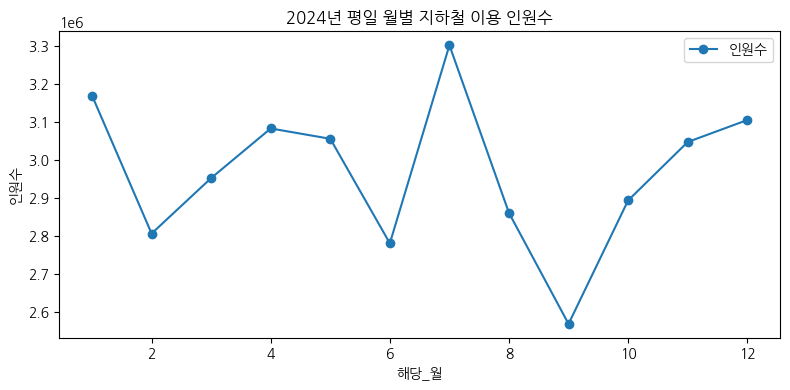

In [56]:
pivot_2024_week = pivot_2024_week.sort_index()

ax = pivot_2024_week.plot(
    y='인원수', kind='line', marker='o', figsize=(8, 4)
)
ax.set_title('2024년 평일 월별 지하철 이용 인원수')
ax.set_xlabel('해당_월')
ax.set_ylabel('인원수')
plt.tight_layout()
plt.show()

In [57]:
kr_holidays = holidays.KR(years=parking['년도'])

parking['공휴일여부'] = np.where(
    parking['날짜'].isin(kr_holidays),
    "공휴일",
    np.where(
        parking['날짜'].dt.weekday >= 5,
        '주말',
        '평일'
    )
)


In [58]:
parking['공휴일여부'] =parking['공휴일여부'].apply(
    lambda x: '쉬는날' if x in ['주말', '공휴일'] else '평일'
)

In [59]:
parking.head()

,지구별,주차장명,주차대수,이용시간,날짜,평균이용시간,년도,월,일,공휴일여부
0,PLT-010,잠원2-6주차장,2350,227695,2024-12-31,96.8914894,2024,12,31,평일
1,PLT-010,잠원1주차장,290,20877,2024-12-31,71.9896552,2024,12,31,평일
2,PLT-010,잠원2-6주차장,2312,226340,2024-12-30,97.8979239,2024,12,30,평일
3,PLT-010,잠원1주차장,278,23471,2024-12-30,84.4280576,2024,12,30,평일
4,PLT-010,잠원2-6주차장,2324,222207,2024-12-29,95.6140275,2024,12,29,쉬는날


In [60]:
parking_1 = parking[parking['주차장명'].str.contains('1')]
parking_2to6 = parking[parking['주차장명'].str.contains('2')]

In [61]:
parking_1.groupby(['주차장명','년도','월','일'])['주차대수'].sum().reset_index()
parking_2to6.groupby(['주차장명','년도','월','일'])['주차대수'].sum().reset_index()

,주차장명,년도,월,일,주차대수
0,잠원2-6주차장,2023,1,1,2305
1,잠원2-6주차장,2023,1,2,1279
2,잠원2-6주차장,2023,1,3,1194
3,잠원2-6주차장,2023,1,4,1246
4,잠원2-6주차장,2023,1,5,1332
...,...,...,...,...,...
723,잠원2-6주차장,2024,12,27,2060
724,잠원2-6주차장,2024,12,28,2367
725,잠원2-6주차장,2024,12,29,2324
726,잠원2-6주차장,2024,12,30,2312


## 2025, 2024, 2023년의 상관계수를 서로 확인하는게 중요할 것이다!!

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

def plot_daily_two_years_by_month(df, years=(2023, 2024), title_prefix='', treat_zero_as_na=False):
    y1, y2 = years

    d = df.copy()
    d['년도'] = d['년도'].astype(int)
    d['월'] = d['월'].astype(int)
    d['일'] = d['일'].astype(int)

    g = (d.groupby(['년도','월','일'])['주차대수'].sum().reset_index())

    corrs = []
    for m in range(1, 13):
        s1 = g[(g['년도']==y1) & (g['월']==m)].set_index('일')['주차대수'].sort_index()
        s2 = g[(g['년도']==y2) & (g['월']==m)].set_index('일')['주차대수'].sort_index()

        pair = pd.concat([s1.rename(y1), s2.rename(y2)], axis=1)
        if treat_zero_as_na:
            pair = pair.replace(0, np.nan)
        pair = pair.dropna()

        r = pair[y1].corr(pair[y2]) if len(pair) >= 2 else np.nan
        corrs.append((m, r, len(pair)))

        max_days = max(calendar.monthrange(y1, m)[1], calendar.monthrange(y2, m)[1])
        x = range(1, max_days+1)

        plt.figure(figsize=(8, 3.2))
        plt.plot(x, s1.reindex(x).values, marker='o', linewidth=1, label=str(y1))
        plt.plot(x, s2.reindex(x).values, marker='o', linewidth=1, label=str(y2))  # ← 수정
        plt.title(f"{title_prefix}{m}월 일별 주차대수 (r={r:.3f} / n={len(pair)})")
        plt.xlabel('일'); plt.ylabel('주차대수')
        plt.xlim(1, max_days)
        plt.legend()
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    corr_df = pd.DataFrame(corrs, columns=['월','피어슨r','공통일수'])
    print(corr_df)


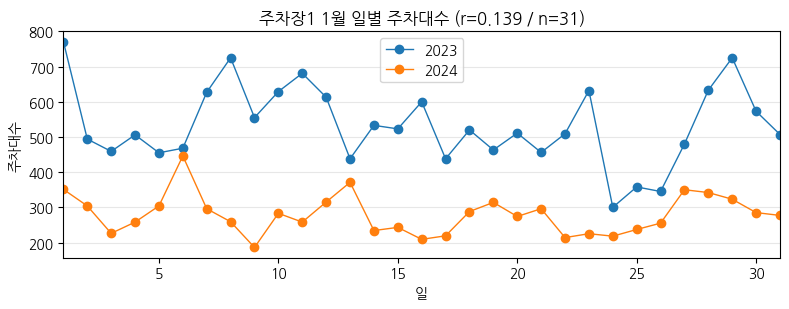

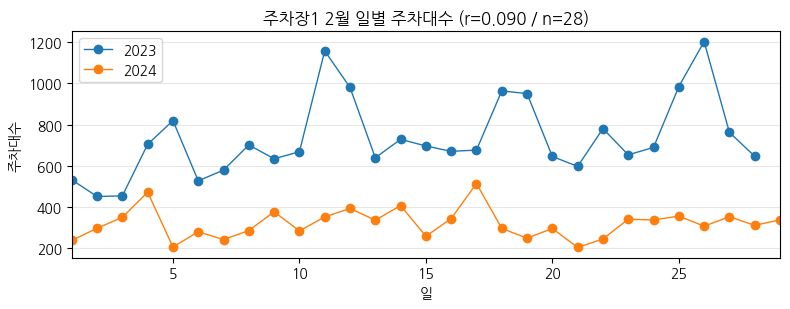

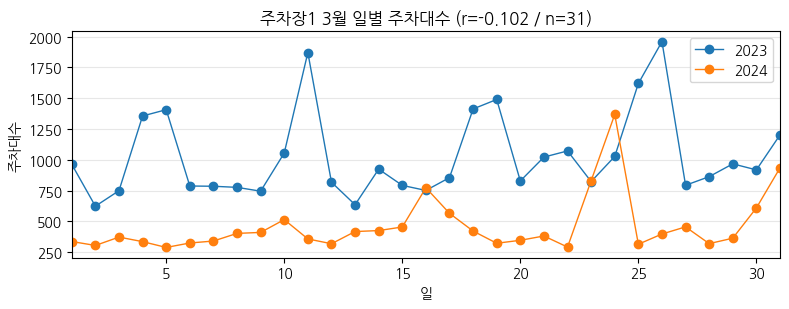

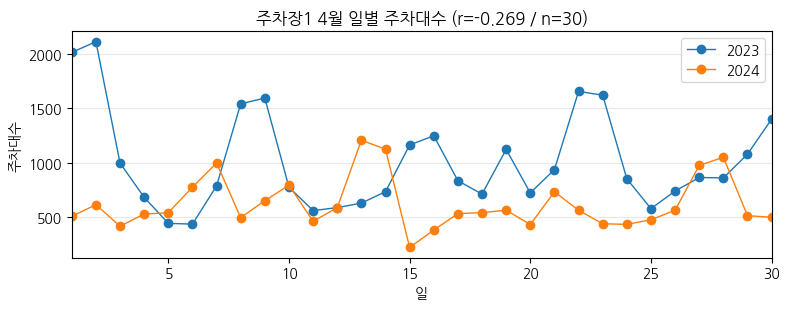

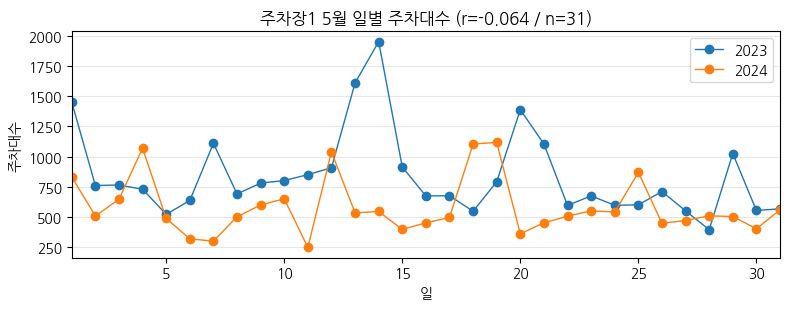

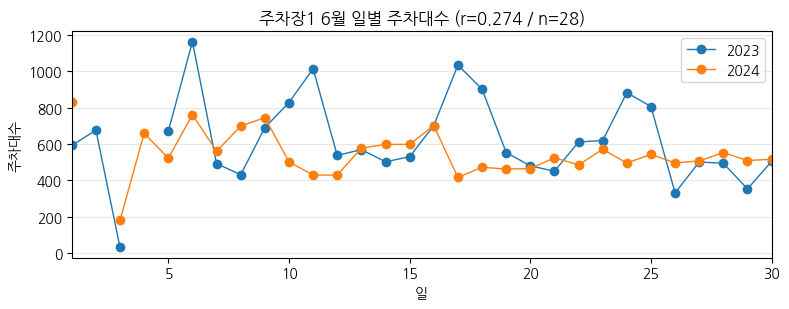

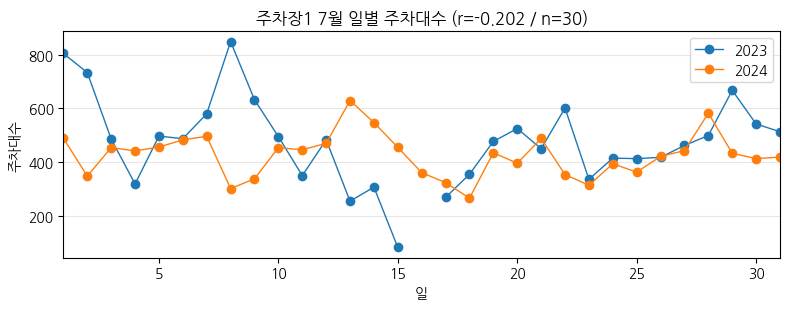

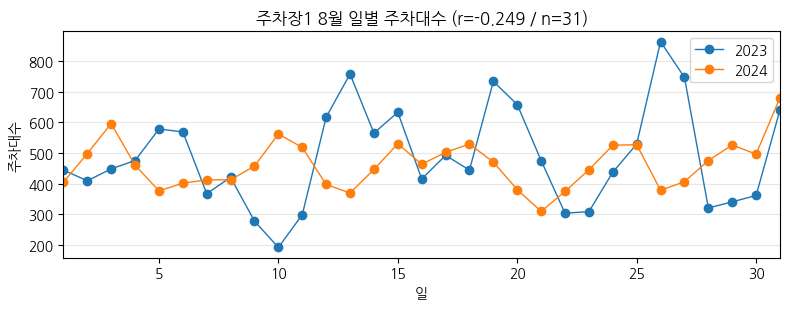

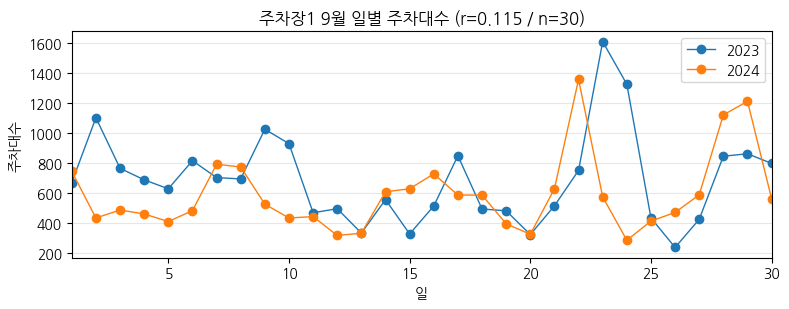

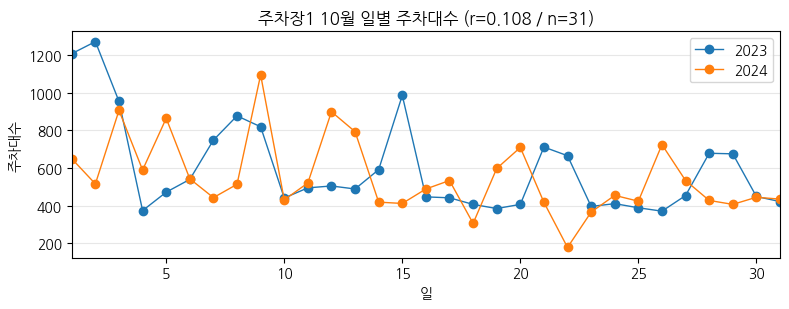

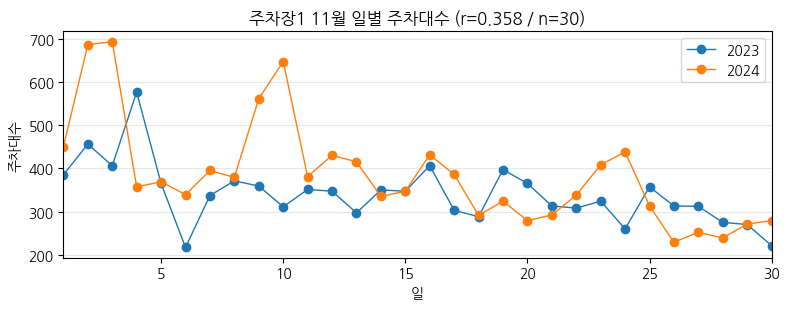

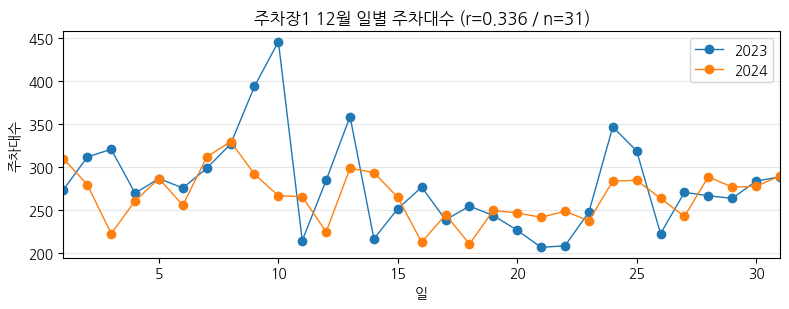

     월       피어슨r  공통일수
0    1  0.1386656    31
1    2  0.0898261    28
2    3 -0.1019820    31
3    4 -0.2694353    30
4    5 -0.0639627    31
5    6  0.2744382    28
6    7 -0.2018796    30
7    8 -0.2488095    31
8    9  0.1146935    30
9   10  0.1075869    31
10  11  0.3580216    30
11  12  0.3363910    31


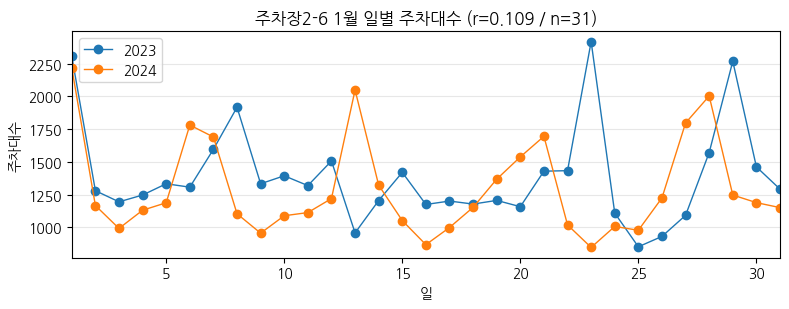

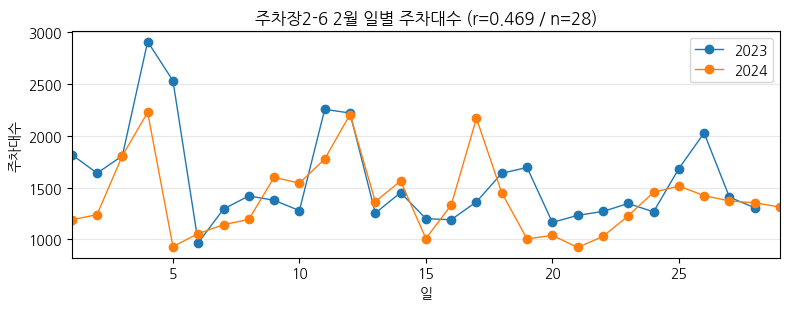

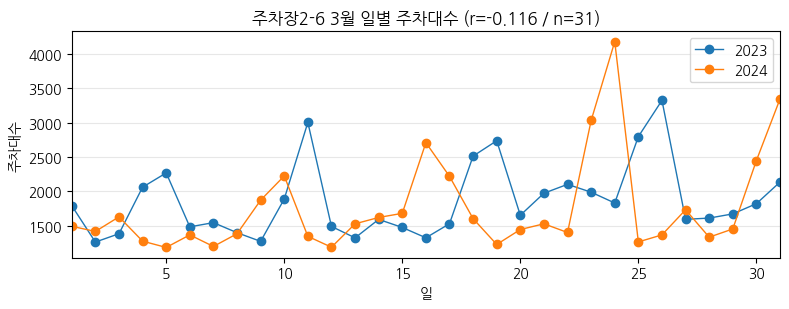

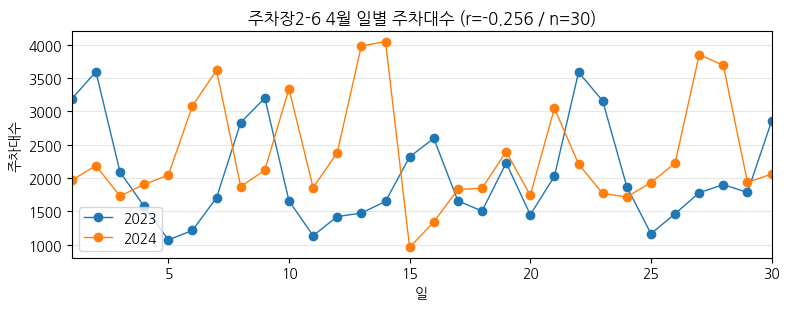

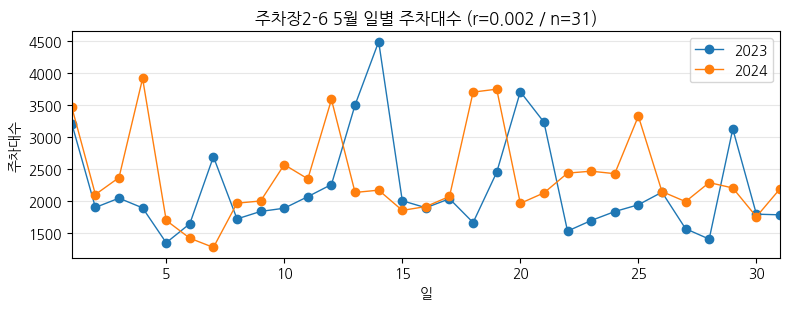

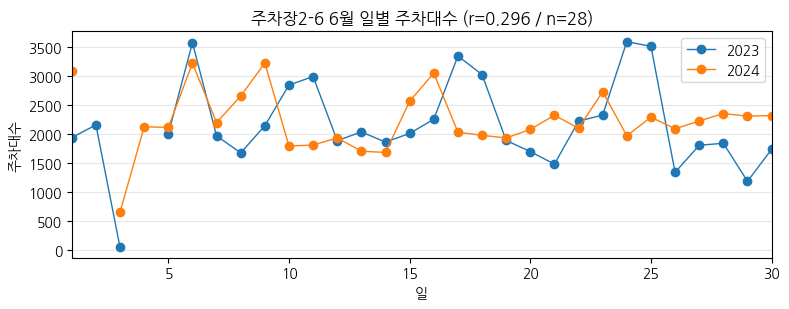

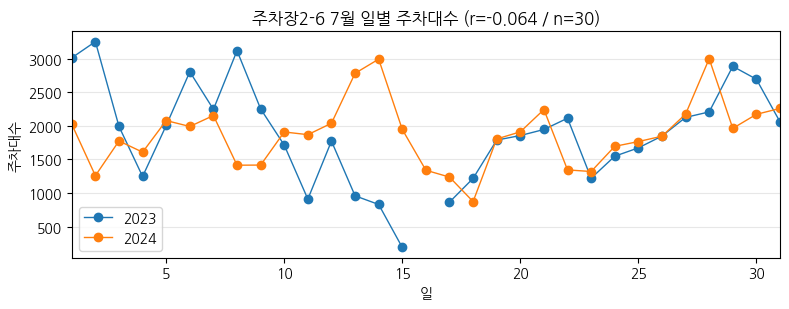

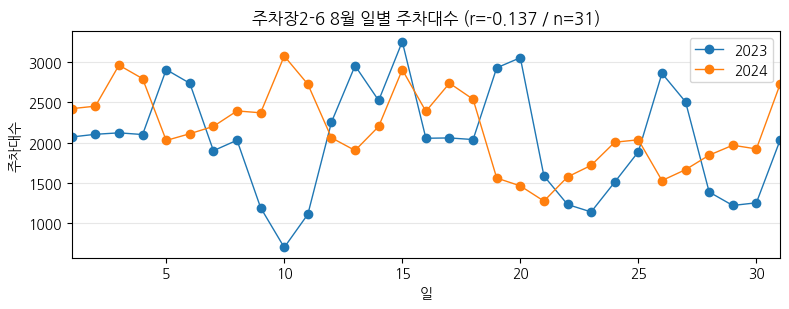

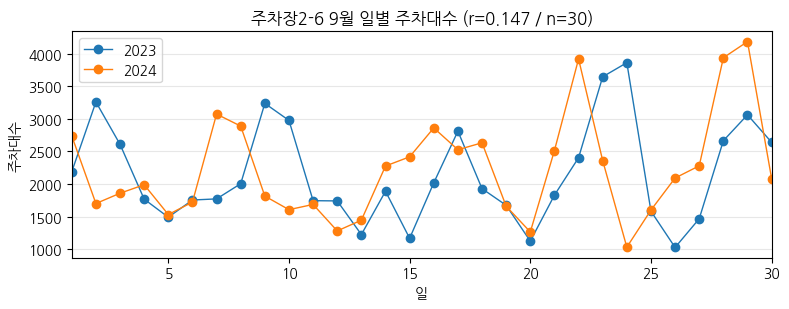

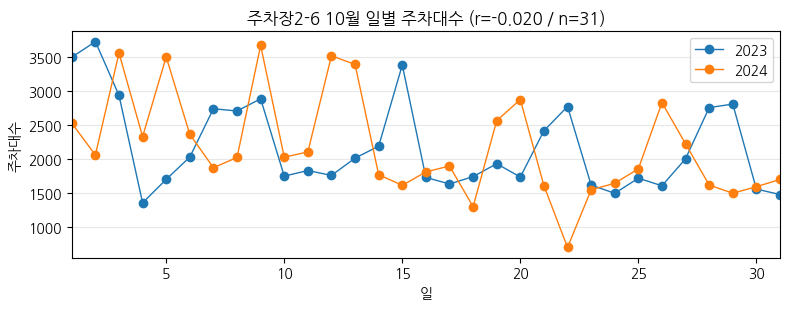

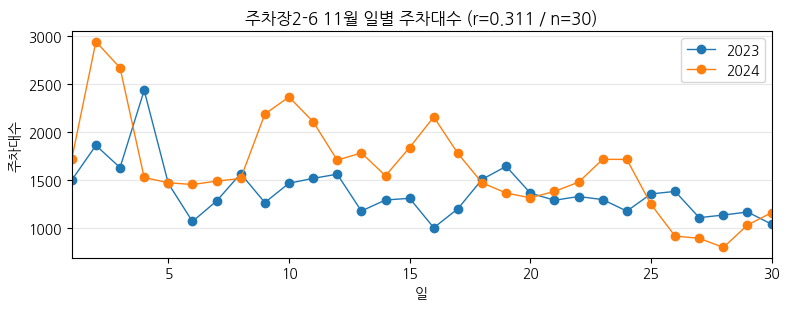

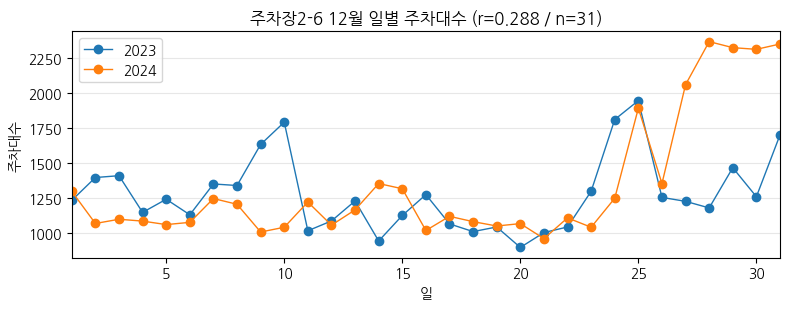

     월       피어슨r  공통일수
0    1  0.1091748    31
1    2  0.4694722    28
2    3 -0.1161925    31
3    4 -0.2560694    30
4    5  0.0021787    31
5    6  0.2962469    28
6    7 -0.0635250    30
7    8 -0.1369192    31
8    9  0.1473055    30
9   10 -0.0202523    31
10  11  0.3112667    30
11  12  0.2883894    31


In [63]:
plot_daily_two_years_by_month(parking_1, years=(2023, 2024), title_prefix='주차장1 ')
plot_daily_two_years_by_month(parking_2to6, years=(2023, 2024), title_prefix='주차장2-6 ')


## 2024년만 사용하면 될 것으로 예상!!

In [64]:
잠원_holi = parking[parking['공휴일여부'] == '쉬는날']
잠원_week = parking[parking['공휴일여부'] == '평일']

In [65]:
grp_holi_잠원 = 잠원_holi.groupby(['주차장명','년도','월','일'])['주차대수'].sum().reset_index()
grp_week_잠원 = 잠원_week.groupby(['주차장명','년도','월'])['주차대수'].sum().reset_index()

In [66]:
grp_holi_잠원_평균 = 잠원_holi.groupby(['주차장명','년도','월'])['주차대수'].mean().reset_index()
grp_week_잠원_평균 = 잠원_week.groupby(['주차장명','년도','월'])['주차대수'].mean().reset_index()

In [67]:
parking_1_week = grp_week_잠원[grp_week_잠원['주차장명'].str.contains('1')]
parking_1_holi = grp_holi_잠원[grp_holi_잠원['주차장명'].str.contains('1')]
parking_2to6_week = grp_week_잠원[grp_week_잠원['주차장명'].str.contains('2')]
parking_2to6_holi = grp_holi_잠원[grp_holi_잠원['주차장명'].str.contains('2')]

In [68]:
parking_1_week_평균 = grp_week_잠원_평균[grp_week_잠원_평균['주차장명'].str.contains('1')]
parking_1_holi_평균 = grp_holi_잠원_평균[grp_holi_잠원_평균['주차장명'].str.contains('1')]
parking_2to6_week_평균 = grp_week_잠원_평균[grp_week_잠원_평균['주차장명'].str.contains('2')]
parking_2to6_holi_평균 = grp_holi_잠원_평균[grp_holi_잠원_평균['주차장명'].str.contains('2')]

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) 월 누락 채움 + 중복 월 집계
# -----------------------------
def fill_missing_months(
    df, 
    year_col='년도', month_col='월', value_col='주차대수',
    agg='sum', fill_value=0
):
    """
    연도별로 월 1~12를 모두 갖도록 누락월을 채웁니다.
    동일 연/월 중복행이 있으면 agg로 집계('sum' 또는 'mean' 추천).
    """
    need_cols = [year_col, month_col, value_col]
    df = df[need_cols].copy()
    # dtype 안전화
    df[year_col]  = pd.to_numeric(df[year_col], errors='coerce').astype('Int64')
    df[month_col] = pd.to_numeric(df[month_col], errors='coerce').astype('Int64')
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')

    # 중복 월 집계
    df = (df
          .dropna(subset=[year_col, month_col])
          .groupby([year_col, month_col], as_index=False)[value_col]
          .agg(agg))

    all_months = pd.Index(range(1, 13), name=month_col)
    filled = []
    for year, sub in df.groupby(year_col, sort=True):
        sub = (sub.set_index(month_col)
                 .reindex(all_months, fill_value=np.nan)
                 .reset_index())
        sub[year_col] = year
        # 누락월 채움값 지정
        if fill_value is not None:
            sub[value_col] = sub[value_col].fillna(fill_value)
        filled.append(sub)
    return pd.concat(filled, ignore_index=True)

# ---------------------------------------
# 2) 연도별 선형 그래프(한 그림에 여러 연도)
#    * 평일/주말은 두 개의 "그림"으로 분리
# ---------------------------------------
def plot_by_year_single(df, title, year_col='년도', month_col='월', value_col='주차대수'):
    """
    한 Figure(차트) 안에 연도별 곡선을 그립니다.
    """
    df_full = fill_missing_months(df, year_col, month_col, value_col, agg='sum', fill_value=0)
    plt.figure(figsize=(10, 5))
    for year, sub in df_full.groupby(year_col, sort=True):
        plt.plot(sub[month_col], sub[value_col], marker='o', label=f'{year}년')
    plt.title(title)
    plt.xlabel('월')
    plt.ylabel(value_col)
    plt.grid(True)
    plt.legend()
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

def plot_week_holi_separate(df_week, df_holi, title_week, title_holi):
    """
    평일/주말 그래프를 '각각 별도 Figure'로 그립니다.
    (보기에도 명확하고, 리포트 삽입 시에도 유용)
    """
    plot_by_year_single(df_week, title_week)
    plot_by_year_single(df_holi, title_holi)

# ---------------------------------------
# 3) 상관계수(두 해 비교) + 전체 연도 상관행렬
# ---------------------------------------
def corr_two_years(
    df, y1=2023, y2=2024, treat_zero_as_na=False, method='pearson',
    year_col='년도', month_col='월', value_col='주차대수'
):
    """
    두 연도의 월별 시계열 상관계수(피어슨/스피어만)를 계산.
    treat_zero_as_na=True이면 0을 결측으로 간주해 공백월 영향 제거.
    """
    df_full = fill_missing_months(df, year_col, month_col, value_col, agg='sum', fill_value=0)
    p = (df_full[df_full[year_col].isin([y1, y2])]
         .pivot(index=month_col, columns=year_col, values=value_col)
         .reindex(range(1, 13)))

    if treat_zero_as_na:
        p = p.replace(0, np.nan)

    p = p.dropna(how='any')
    if p.shape[0] < 2:
        # 공통으로 비교 가능한 월이 1개 이하이면 상관계수 정의가 어려움
        return np.nan
    return p[y1].corr(p[y2], method=method)

def corr_matrix_all_years(
    df, treat_zero_as_na=False, method='pearson',
    year_col='년도', month_col='월', value_col='주차대수'
):
    """
    데이터에 존재하는 모든 연도 간 상관계수 행렬을 반환합니다.
    """
    df_full = fill_missing_months(df, year_col, month_col, value_col, agg='sum', fill_value=0)
    p = (df_full
         .pivot(index=month_col, columns=year_col, values=value_col)
         .reindex(range(1, 13)))
    if treat_zero_as_na:
        p = p.replace(0, np.nan)
    return p.corr(method=method, min_periods=2)

# ---------------------------------------
# 4) 두 해 비교 테이블(월별 값/차이/비율)
# ---------------------------------------
def compare_two_years_table(
    df, y1=2023, y2=2024, treat_zero_as_na=False,
    year_col='년도', month_col='월', value_col='주차대수'
):
    """
    두 연도의 월별 값과 차이/비율을 보여주는 테이블을 반환합니다.
    """
    df_full = fill_missing_months(df, year_col, month_col, value_col, agg='sum', fill_value=0)
    p = (df_full[df_full[year_col].isin([y1, y2])]
         .pivot(index=month_col, columns=year_col, values=value_col)
         .reindex(range(1, 13)))
    if treat_zero_as_na:
        p = p.replace(0, np.nan)

    out = pd.DataFrame({
        '월': range(1, 13),
        f'{y1}년': p.get(y1, pd.Series(index=range(1,13), dtype='float')),
        f'{y2}년': p.get(y2, pd.Series(index=range(1,13), dtype='float'))
    })
    out['차이(2-1)'] = out[f'{y2}년'] - out[f'{y1}년']
    out['비율(2/1)'] = out[f'{y2}년'] / out[f'{y1}년']
    return out


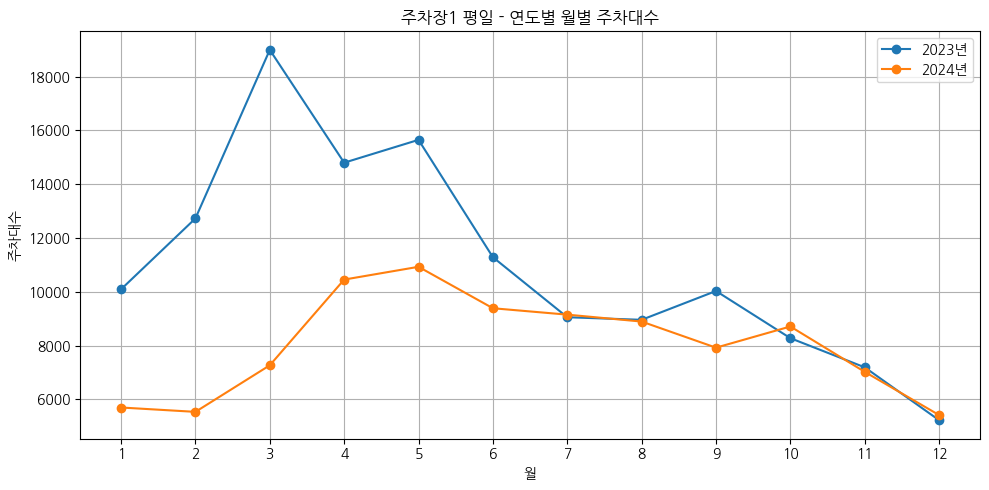

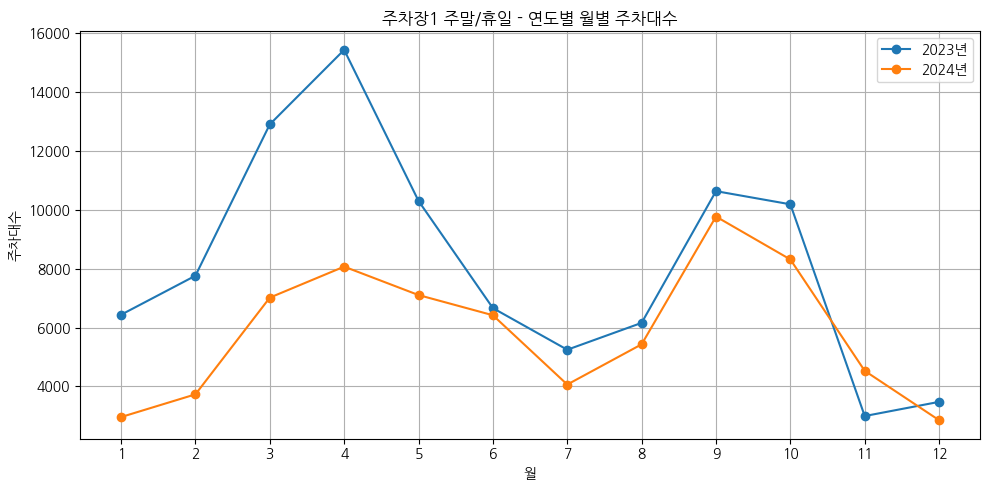

주차장1 평일 상관계수: 0.34753186618280363
주차장1 주말/휴일 상관계수: 0.7535080355284342
     월  2023년  2024년  차이(2-1)   비율(2/1)
월                                      
1    1  10093   5700    -4393 0.5647478
2    2  12727   5538    -7189 0.4351379
3    3  18992   7269   -11723 0.3827401
4    4  14798  10454    -4344 0.7064468
5    5  15647  10929    -4718 0.6984726
6    6  11286   9389    -1897 0.8319156
7    7   9055   9151       96 1.0106019
8    8   8959   8894      -65 0.9927447
9    9  10030   7924    -2106 0.7900299
10  10   8277   8711      434 1.0524345
11  11   7193   7025     -168 0.9766440
12  12   5228   5419      191 1.0365340


In [103]:
# 예) 주차장1
plot_week_holi_separate(
    parking_1_week[['년도','월','주차대수']],
    parking_1_holi[['년도','월','주차대수']],
    '주차장1 평일 - 연도별 월별 주차대수',
    '주차장1 주말/휴일 - 연도별 월별 주차대수'
)

corr_week = corr_two_years(parking_1_week, 2023, 2024, treat_zero_as_na=True, method='pearson')
corr_holi = corr_two_years(parking_1_holi, 2023, 2024, treat_zero_as_na=True, method='pearson')
print('주차장1 평일 상관계수:', corr_week)
print('주차장1 주말/휴일 상관계수:', corr_holi)

# 전체 연도 상관행렬
corr_all_week = corr_matrix_all_years(parking_1_week, treat_zero_as_na=True)
corr_all_holi = corr_matrix_all_years(parking_1_holi, treat_zero_as_na=True)

# 두 해 비교 테이블
tbl = compare_two_years_table(parking_1_week, 2023, 2024, treat_zero_as_na=True)
print(tbl)


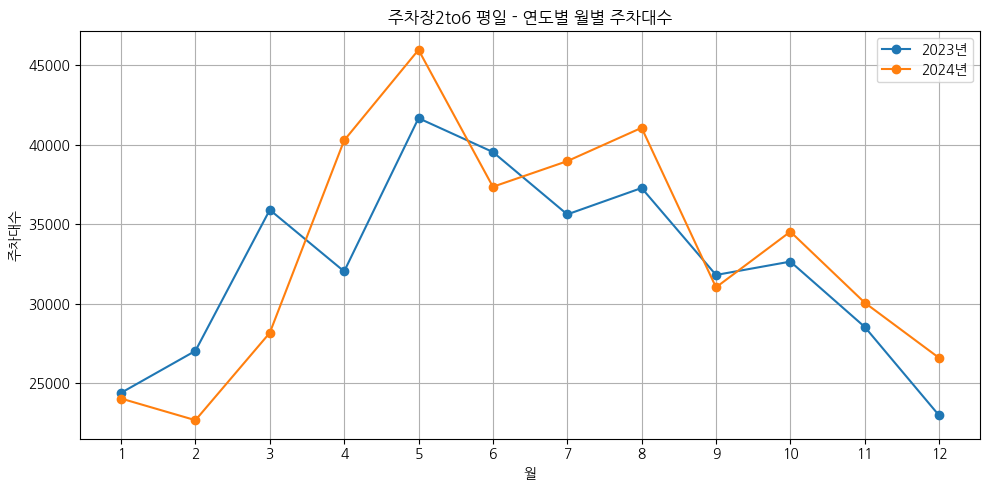

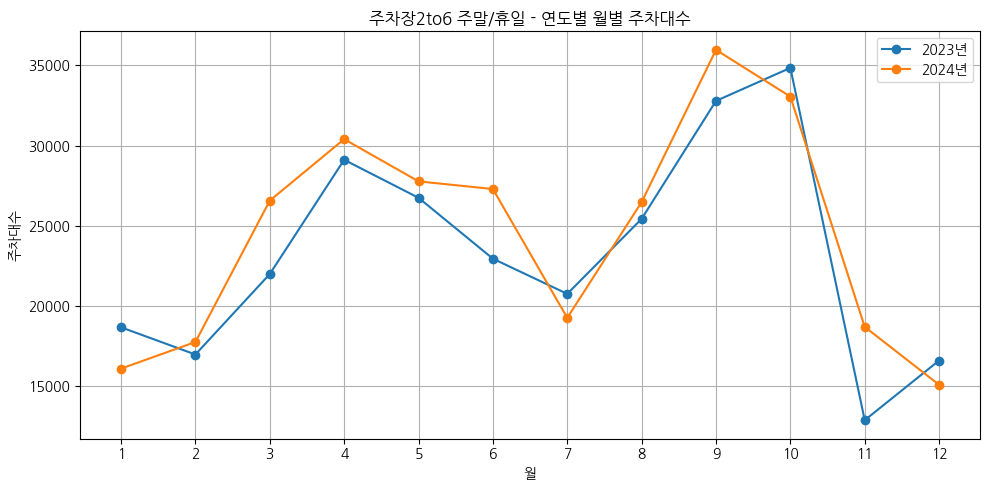

주차장2to6 평일 상관계수: 0.8137563876441439
주차장2to6 주말/휴일 상관계수: 0.9183033565285577
     월  2023년  2024년  차이(2-1)   비율(2/1)
월                                      
1    1  24400  24041     -359 0.9852869
2    2  27036  22680    -4356 0.8388815
3    3  35897  28170    -7727 0.7847452
4    4  32030  40262     8232 1.2570091
5    5  41656  45949     4293 1.1030584
6    6  39529  37346    -2183 0.9447747
7    7  35611  38957     3346 1.0939597
8    8  37269  41051     3782 1.1014784
9    9  31805  31028     -777 0.9755699
10  10  32645  34526     1881 1.0576198
11  11  28541  30064     1523 1.0533618
12  12  22980  26594     3614 1.1572672


In [104]:
# 예) 주차장2to6
plot_week_holi_separate(
    parking_2to6_week[['년도','월','주차대수']],
    parking_2to6_holi[['년도','월','주차대수']],
    '주차장2to6 평일 - 연도별 월별 주차대수',
    '주차장2to6 주말/휴일 - 연도별 월별 주차대수'
)

corr_week = corr_two_years(parking_2to6_week, 2023, 2024, treat_zero_as_na=True, method='pearson')
corr_holi = corr_two_years(parking_2to6_holi, 2023, 2024, treat_zero_as_na=True, method='pearson')
print('주차장2to6 평일 상관계수:', corr_week)
print('주차장2to6 주말/휴일 상관계수:', corr_holi)

# 전체 연도 상관행렬
corr_all_week = corr_matrix_all_years(parking_2to6_week, treat_zero_as_na=True)
corr_all_holi = corr_matrix_all_years(parking_2to6_holi, treat_zero_as_na=True)

# 두 해 비교 테이블
tbl = compare_two_years_table(parking_2to6_week, 2023, 2024, treat_zero_as_na=True)
print(tbl)


### 평일이 주말보다 절대적 사용량이 많다

### 

In [74]:
weather = pd.read_csv('../Data/2023-2024날씨_전처리_완.csv')

In [75]:
weather

,풍속(m/s),불쾌지수,날짜,시간_시
0,1.9000000,38.4163500,2023-01-01,1
1,1.9000000,38.2882000,2023-01-01,2
2,1.6000000,38.1861600,2023-01-01,3
3,1.4000000,38.0319000,2023-01-01,4
4,2.4000000,38.5730400,2023-01-01,5
...,...,...,...,...
17491,2.6000000,45.6235200,2024-12-30,20
17492,2.7000000,44.9694800,2024-12-30,21
17493,2.4000000,43.5602100,2024-12-30,22
17494,0.7000000,41.9402500,2024-12-30,23


In [76]:
weather['날짜'] = pd.to_datetime(weather['날짜'], format='%Y-%m-%d')

In [77]:
drop_to_idx = weather[(weather['시간_시'] == 0)| (weather['시간_시'] == 1) | (weather['시간_시'] == 2) | (weather['시간_시'] == 3) |(weather['시간_시'] == 4) |(weather['시간_시'] == 5)].index

In [78]:
weather.drop(drop_to_idx,axis='rows',inplace=True)

In [79]:
weather['연도'] = weather['날짜'].dt.year
weather['월'] = weather['날짜'].dt.month
weather['일'] = weather['날짜'].dt.day

In [80]:
weather.columns

Index(['풍속(m/s)', '불쾌지수', '날짜', '시간_시', '연도', '월', '일'], dtype='object')

In [81]:
kr_holidays = holidays.KR(years=[2023,2024])

weather['공휴일여부'] = np.where(
    weather['날짜'].isin(kr_holidays),
    "공휴일",
    np.where(
        weather['날짜'].dt.weekday >= 5,
        '주말',
        '평일'
    )
)

weather['공휴일여부'] = weather['공휴일여부'].apply(
    lambda x: '쉬는날' if x in ['주말', '공휴일'] else '평일'
)


In [82]:
weather_holi = weather[weather['공휴일여부'] == '쉬는날']
weather_week = weather[weather['공휴일여부'] == '평일']

In [83]:
weather_holi_평균 = weather_holi.groupby(['연도','월'])['불쾌지수'].mean().reset_index()
weather_week_평균 = weather_week.groupby(['연도','월'])['불쾌지수'].mean().reset_index()

In [84]:
weather_holi_평균.head()

,연도,월,불쾌지수
0,2023,1,35.3432901
1,2023,2,42.6051090
2,2023,3,51.3787005
3,2023,4,57.7976346
4,2023,5,64.5923292


In [85]:
def fill_missing_months(df):
    """연도별로 월 1~12 누락 채움 (없는 달은 0)"""
    all_months = pd.Index(range(1, 13), name='월')
    filled = []
    for year, sub in df.groupby('연도', sort=True):
        sub = (sub.set_index('월')
                  .reindex(all_months, fill_value=0)
                  .reset_index())
        sub['연도'] = year
        filled.append(sub)
    return pd.concat(filled, ignore_index=True)

def plot_week_holi_together(df_week, df_holi, title_week, title_holi):
    """한 Figure에 평일/주말 두 그래프를 그립니다."""
    df_week_full = fill_missing_months(df_week)
    df_holi_full = fill_missing_months(df_holi)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # 평일 그래프
    for year, sub in df_week_full.groupby('연도', sort=True):
        axes[0].plot(sub['월'], sub['불쾌지수'], marker='o', label=f'{year}년')
    axes[0].set_title(title_week)
    axes[0].set_ylabel('불쾌지수')
    axes[0].grid(True)
    axes[0].legend()

    # 주말 그래프
    for year, sub in df_holi_full.groupby('연도', sort=True):
        axes[1].plot(sub['월'], sub['불쾌지수'], marker='o', label=f'{year}년')
    axes[1].set_title(title_holi)
    axes[1].set_xlabel('월')
    axes[1].set_ylabel('불쾌지수')
    axes[1].grid(True)
    axes[1].legend()

    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

def corr_two_years(df, y1=2023, y2=2024, treat_zero_as_na=False):
    """df: 컬럼에 ['년도','월','주차대수']가 있는 DataFrame"""
    # 월 1~12 모두 채워 정렬
    df_full = fill_missing_months(df[['년도','월','주차대수']])
    p = (df_full[df_full['년도'].isin([y1, y2])]
         .pivot(index='월', columns='년도', values='주차대수')
         .reindex(range(1,13)))

    # 0을 결측으로 취급하고 싶으면(누락 채움 0이 상관계수에 영향 주는 게 싫을 때)
    if treat_zero_as_na:
        p = p.replace(0, np.nan)

    # 두 해 모두 값이 있는 월만 사용
    p = p.dropna(how='any')
    return p[y1].corr(p[y2], method='pearson')  # 피어슨 상관계수

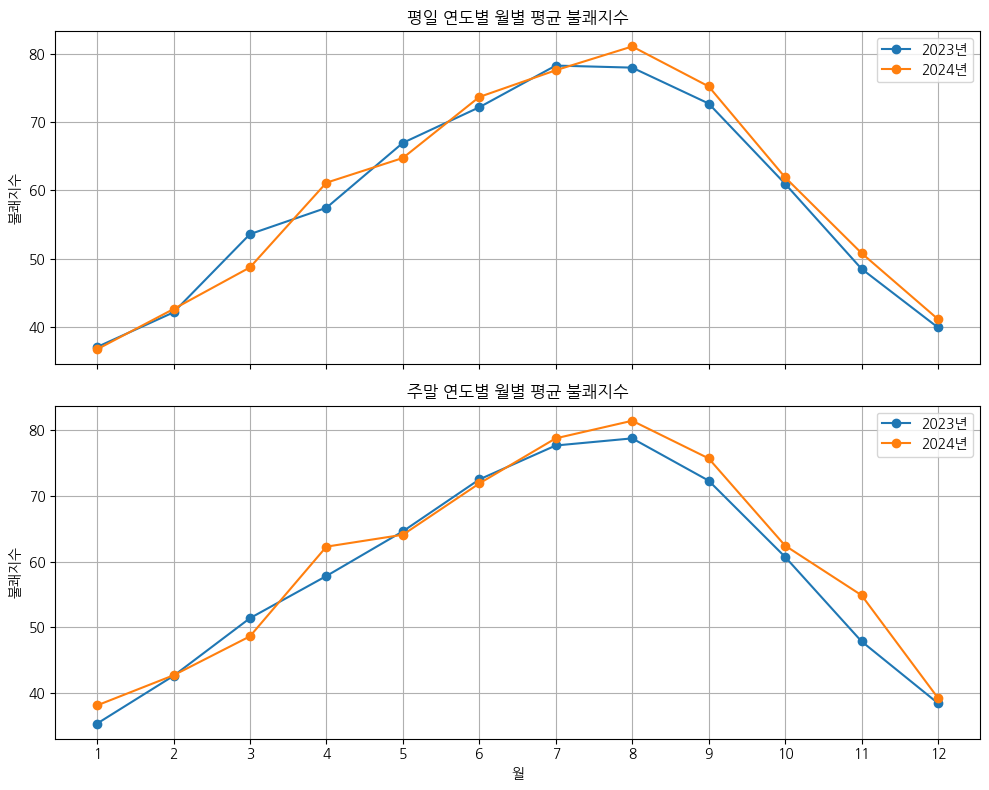

In [86]:
# 사용 예시
plot_week_holi_together(
    weather_week_평균[['연도','월','불쾌지수']],
    weather_holi_평균[['연도','월','불쾌지수']],
    '평일 연도별 월별 평균 불쾌지수',
    '주말 연도별 월별 평균 불쾌지수'
)

In [87]:
people_2023 = pd.read_csv("../Data/잠원_유동인구_2023_년월일요일일자구분.csv")
people_2024 = pd.read_csv("../Data/잠원_유동인구_2024_년월일요일일자구분.csv")

In [88]:
people = pd.concat([people_2023,people_2024])

In [89]:
people_유출 = people[(people['출발_행정동코드'] == 11680510) | (people['출발_행정동코드'] == 11650540)]
people_유입 = people[(people['도착_행정동코드'] == 11680510) | (people['도착_행정동코드'] == 11650540)]

## 우선 23년도 유출만 확인

In [90]:
people_유출_holi = people_유출[people_유출['일자_구분'] == '쉬는날']
people_유출_week = people_유출[people_유출['일자_구분'] == '평일']
people_유입_holi = people_유입[people_유입['일자_구분'] == '쉬는날']
people_유입_week = people_유입[people_유입['일자_구분'] == '평일']

In [91]:
grp_holi_people_유출 = people_유출_holi.groupby(['년','월'])['이동인원수'].sum().reset_index()
grp_week_people_유출 = people_유출_week.groupby(['년','월'])['이동인원수'].sum().reset_index()
grp_holi_people_유입 = people_유입_holi.groupby(['년','월'])['이동인원수'].sum().reset_index()
grp_week_people_유입 = people_유입_week.groupby(['년','월'])['이동인원수'].sum().reset_index()

In [92]:
def fill_missing_months(df):
    """년별로 월 1~12 누락 채움 (없는 달은 0)"""
    all_months = pd.Index(range(1, 13), name='월')
    filled = []
    for year, sub in df.groupby('년', sort=True):
        sub = (sub.set_index('월')
                  .reindex(all_months, fill_value=0)
                  .reset_index())
        sub['년'] = year
        filled.append(sub)
    return pd.concat(filled, ignore_index=True)

def plot_week_holi_together(df_week, df_holi, title_week, title_holi):
    """한 Figure에 평일/주말 두 그래프를 그립니다."""
    df_week_full = fill_missing_months(df_week)
    df_holi_full = fill_missing_months(df_holi)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # 평일 그래프
    for year, sub in df_week_full.groupby('년', sort=True):
        axes[0].plot(sub['월'], sub['이동인원수'], marker='o', label=f'{year}년')
    axes[0].set_title(title_week)
    axes[0].set_ylabel('이동인원수')
    axes[0].grid(True)
    axes[0].legend()

    # 주말 그래프
    for year, sub in df_holi_full.groupby('년', sort=True):
        axes[1].plot(sub['월'], sub['이동인원수'], marker='o', label=f'{year}년')
    axes[1].set_title(title_holi)
    axes[1].set_xlabel('월')
    axes[1].set_ylabel('이동인원수')
    axes[1].grid(True)
    axes[1].legend()

    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

def corr_two_years(df, y1=2023, y2=2024, treat_zero_as_na=False):
    """df: 컬럼에 ['년','월','이동인원수']가 있는 DataFrame"""
    # 월 1~12 모두 채워 정렬
    df_full = fill_missing_months(df[['년','월','이동인원수']])
    p = (df_full[df_full['년'].isin([y1, y2])]
         .pivot(index='월', columns='년', values='이동인원수')
         .reindex(range(1,13)))

    # 0을 결측으로 취급하고 싶으면(누락 채움 0이 상관계수에 영향 주는 게 싫을 때)
    if treat_zero_as_na:
        p = p.replace(0, np.nan)

    # 두 해 모두 값이 있는 월만 사용
    p = p.dropna(how='any')
    return p[y1].corr(p[y2], method='pearson')

In [93]:
grp_holi_people_유입.head()

,년,월,이동인원수
0,2023,1,1271212.1300000
1,2023,2,1172271.5500000
2,2023,3,1305425.9300000
3,2023,4,1465164.6700000
4,2023,5,1369912.3400000


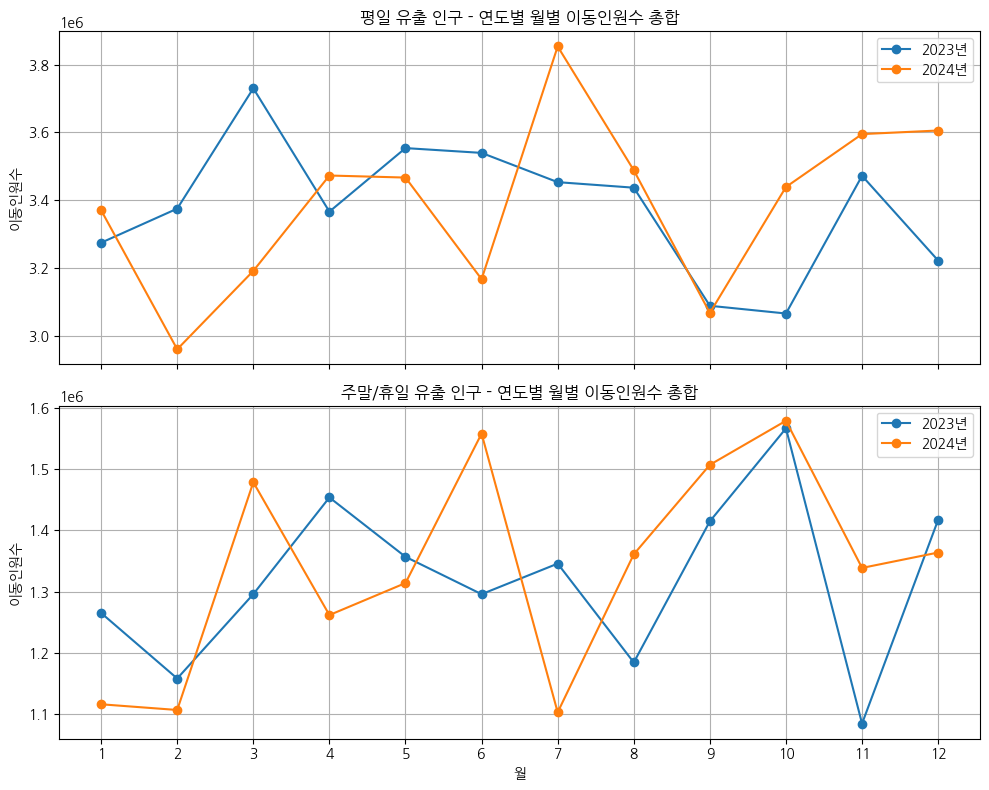

평일 유출 인구 상관계수: 0.026329849556349476
주말/휴일 유출 인구 상관계수: 0.385791567062485


In [94]:
# 사용 예시
plot_week_holi_together(
    grp_week_people_유출[['년','월','이동인원수']],
    grp_holi_people_유출[['년','월','이동인원수']],
    '평일 유출 인구 - 연도별 월별 이동인원수 총합',
    '주말/휴일 유출 인구 - 연도별 월별 이동인원수 총합'
)
# 예) 주차장2to6
corr_week  = corr_two_years(grp_week_people_유출, 2023, 2024, treat_zero_as_na=True)
corr_holi  = corr_two_years(grp_holi_people_유출, 2023, 2024, treat_zero_as_na=True)
print('평일 유출 인구 상관계수:', corr_week)
print('주말/휴일 유출 인구 상관계수:', corr_holi)

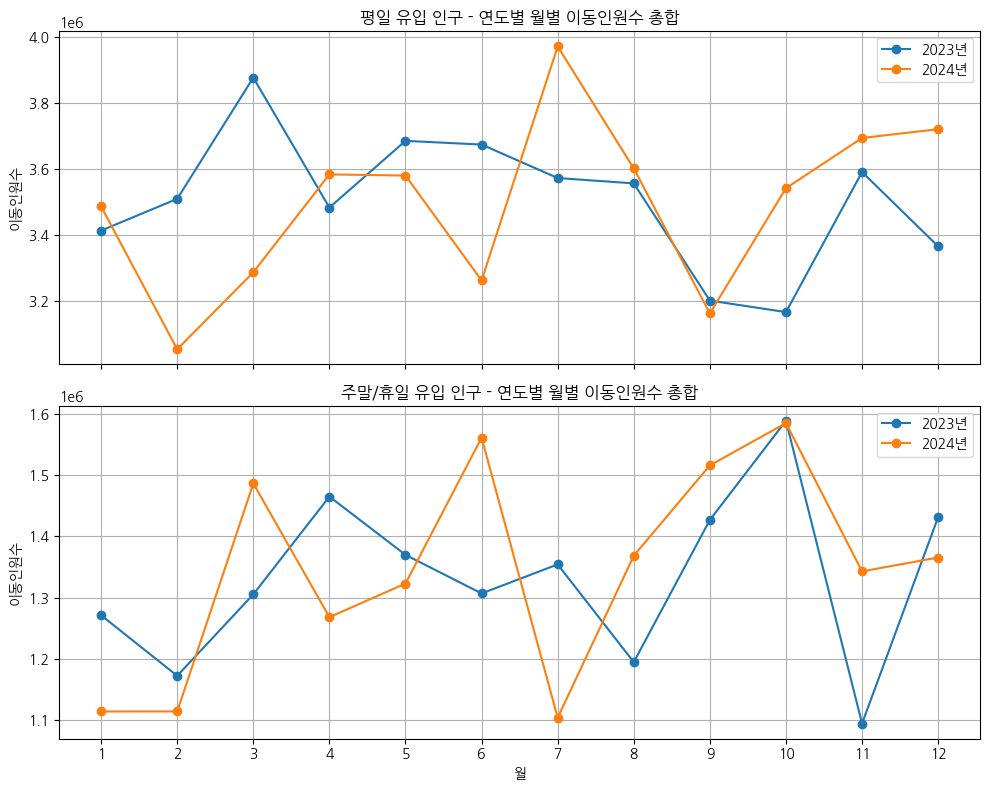

In [95]:
# 사용 예시
plot_week_holi_together(
    grp_week_people_유입[['년','월','이동인원수']],
    grp_holi_people_유입[['년','월','이동인원수']],
    '평일 유입 인구 - 연도별 월별 이동인원수 총합',
    '주말/휴일 유입 인구 - 연도별 월별 이동인원수 총합'
)

In [97]:
bus_station = pd.read_csv('../Data/서울시 버스정류소 위치정보.csv',encoding='cp949')

In [105]:
bus_station.head()

,노드 ID,정류소번호,정류소명,X좌표,Y좌표,정류소 타입
0,100000001,1001,종로2가사거리,126.9877520,37.5698080,중앙차로
1,100000002,1002,창경궁.서울대학교병원,126.9965220,37.5794330,중앙차로
2,100000003,1003,명륜3가.성대입구,126.9982510,37.5825810,중앙차로
3,100000004,1004,종로2가.삼일교,126.9876131,37.5685793,중앙차로
4,100000005,1005,혜화동로터리.여운형활동터,127.0017440,37.5862430,중앙차로


In [122]:
bus = pd.read_csv("../23-24년 버스정류장 일별/BUS_STATION_BOARDING_MONTH_202301.csv",encoding='cp949')

In [123]:
bus.head()

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
0,20230101,100,100번(하계동~용산구청),100000002,01002,창경궁.서울대학교병원(00031),33,47,20230104
1,20230101,9401,9401번(구미동~서울역),206000321,47024,샛별마을.우방아파트(00015),76,1,20230104
2,20230101,9401,9401번(구미동~서울역),206000320,47022,중앙공원.샛별마을.라이프아파트(00016),55,8,20230104
3,20230101,9401,9401번(구미동~서울역),206000319,47054,효자촌(00017),363,21,20230104
4,20230101,9401,9401번(구미동~서울역),206000318,47065,서현중학교(00018),133,25,20230104


In [126]:
bus_01 = bus[bus['역명'].str.contains("한남대교전망카페")]

In [127]:
bus_01.역명.unique()

array(['한남대교전망카페(00063)', '한남대교전망카페(00073)', '한남대교전망카페(00059)',
       '한남대교전망카페(00016)', '한남대교전망카페(00054)', '한남대교전망카페(00039)',
       '한남대교전망카페(00042)', '한남대교전망카페(00020)', '한남대교전망카페(00024)',
       '한남대교전망카페(00068)', '한남대교전망카페(00069)'], dtype=object)

In [128]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("../23-24년 버스정류장 일별")
YEAR = 2023
FILE_FMT = "BUS_STATION_BOARDING_MONTH_{}{:02d}.csv"  # ..._202301.csv ~ ..._202312.csv
KEYWORD = "한남대교전망카페"

def concat_station_year_simple(base_dir=BASE_DIR, year=YEAR, keyword=KEYWORD):
    frames = []
    for m in range(1, 13):
        fpath = base_dir / FILE_FMT.format(year, m)
        if not fpath.exists():
            print(f"[WARN] 없음: {fpath.name}")
            continue

        df = pd.read_csv(fpath, encoding="cp949", dtype=str, low_memory=False)
        if "역명" not in df.columns:
            raise KeyError(f"'역명' 컬럼이 없습니다. 실제 컬럼: {list(df.columns)[:10]} ...")

        sub = df[df["역명"].astype(str).str.contains(keyword, na=False, regex=False)]
        if not sub.empty:
            frames.append(sub)

    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

# 사용 예
result = concat_station_year_simple()
print(result.shape)   # (행수, 열수)
result.head()


(4380, 9)


,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
0,20230101,470,470번(상암차고지~안골마을),122000408,23531,한남대교전망카페(00063),27,16,20230104
1,20230101,741,741번(진관차고지~헌인릉입구),122000408,23531,한남대교전망카페(00073),16,17,20230104
2,20230101,144,144번(우이동~교대),122000408,23531,한남대교전망카페(00059),14,14,20230104
3,20230101,400,400번(염곡동~시청),122000408,23531,한남대교전망카페(00016),12,6,20230104
4,20230101,140,140번(도봉산역~AT센터),122000408,23531,한남대교전망카페(00054),20,21,20230104


In [132]:
result_2023 = result

In [133]:
result_2023.head()

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
0,20230101,470,470번(상암차고지~안골마을),122000408,23531,한남대교전망카페(00063),27,16,20230104
1,20230101,741,741번(진관차고지~헌인릉입구),122000408,23531,한남대교전망카페(00073),16,17,20230104
2,20230101,144,144번(우이동~교대),122000408,23531,한남대교전망카페(00059),14,14,20230104
3,20230101,400,400번(염곡동~시청),122000408,23531,한남대교전망카페(00016),12,6,20230104
4,20230101,140,140번(도봉산역~AT센터),122000408,23531,한남대교전망카페(00054),20,21,20230104


In [ ]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("../23-24년 버스정류장 일별")
YEAR = 2024
FILE_FMT = "BUS_STATION_BOARDING_MONTH_{}{:02d}.csv"  
KEYWORD = "한남대교전망카페"

def concat_station_year_simple(base_dir=BASE_DIR, year=YEAR, keyword=KEYWORD):
    frames = []
    for m in range(1, 13):
        fpath = base_dir / FILE_FMT.format(year, m)
        if not fpath.exists():
            print(f"[WARN] 없음: {fpath.name}")
            continue

        df = pd.read_csv(fpath, encoding="cp949", dtype=str, low_memory=False)
        if "역명" not in df.columns:
            raise KeyError(f"'역명' 컬럼이 없습니다. 실제 컬럼: {list(df.columns)[:10]} ...")

        sub = df[df["역명"].astype(str).str.contains(keyword, na=False, regex=False)]
        if not sub.empty:
            frames.append(sub)

    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

# 사용 예
result_2024 = concat_station_year_simple()
print(result.shape)   # (행수, 열수)



(4380, 9)


,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
0,20230101,470,470번(상암차고지~안골마을),122000408,23531,한남대교전망카페(00063),27,16,20230104
1,20230101,741,741번(진관차고지~헌인릉입구),122000408,23531,한남대교전망카페(00073),16,17,20230104
2,20230101,144,144번(우이동~교대),122000408,23531,한남대교전망카페(00059),14,14,20230104
3,20230101,400,400번(염곡동~시청),122000408,23531,한남대교전망카페(00016),12,6,20230104
4,20230101,140,140번(도봉산역~AT센터),122000408,23531,한남대교전망카페(00054),20,21,20230104


In [136]:
result_2023.head()

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
0,20230101,470,470번(상암차고지~안골마을),122000408,23531,한남대교전망카페(00063),27,16,20230104
1,20230101,741,741번(진관차고지~헌인릉입구),122000408,23531,한남대교전망카페(00073),16,17,20230104
2,20230101,144,144번(우이동~교대),122000408,23531,한남대교전망카페(00059),14,14,20230104
3,20230101,400,400번(염곡동~시청),122000408,23531,한남대교전망카페(00016),12,6,20230104
4,20230101,140,140번(도봉산역~AT센터),122000408,23531,한남대교전망카페(00054),20,21,20230104


In [137]:
result_2023['사용일자'] = pd.to_datetime(result_2023['사용일자'], format="%Y%m%d")

In [139]:
result_2023['해당_년'] = result_2023['사용일자'].dt.year
result_2023['해당_월'] = result_2023['사용일자'].dt.month
result_2023['해당_일'] = result_2023['사용일자'].dt.day

In [142]:
result_2023['역명'] = "한남대교전망카페"

In [156]:
result_2023['하차총승객수'] = result_2023.하차총승객수.astype(int)

In [157]:
result_2023['승차총승객수'] = result_2023.승차총승객수.astype(int)

In [ ]:
result_2023

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   사용일자        4380 non-null   datetime64[ns]
 1   노선번호        4380 non-null   object        
 2   노선명         4380 non-null   object        
 3   표준버스정류장ID   4380 non-null   object        
 4   버스정류장ARS번호  4380 non-null   object        
 5   역명          4380 non-null   object        
 6   승차총승객수      4380 non-null   object        
 7   하차총승객수      4380 non-null   object        
 8   등록일자        4380 non-null   object        
 9   해당_년        4380 non-null   int32         
 10  해당_월        4380 non-null   int32         
 11  해당_일        4380 non-null   int32         
dtypes: datetime64[ns](1), int32(3), object(8)
memory usage: 359.4+ KB


In [147]:
result_2023[result_2023.사용일자 == "2023-01-01"]

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자,해당_년,해당_월,해당_일
0,2023-01-01,470,470번(상암차고지~안골마을),122000408,23531,한남대교전망카페,27,16,20230104,2023,1,1
1,2023-01-01,741,741번(진관차고지~헌인릉입구),122000408,23531,한남대교전망카페,16,17,20230104,2023,1,1
2,2023-01-01,144,144번(우이동~교대),122000408,23531,한남대교전망카페,14,14,20230104,2023,1,1
3,2023-01-01,400,400번(염곡동~시청),122000408,23531,한남대교전망카페,12,6,20230104,2023,1,1
4,2023-01-01,140,140번(도봉산역~AT센터),122000408,23531,한남대교전망카페,20,21,20230104,2023,1,1
5,2023-01-01,421,421번(염곡동~옥수동),122000408,23531,한남대교전망카페,54,22,20230104,2023,1,1
6,2023-01-01,402,402번(장지공영차고지~광화문),122000408,23531,한남대교전망카페,28,38,20230104,2023,1,1
7,2023-01-01,3011,3011번(장지공영차고지~한남동),122000408,23531,한남대교전망카페,2,40,20230104,2023,1,1
8,2023-01-01,420,420번(개포동~답십리역),122000408,23531,한남대교전망카페,53,46,20230104,2023,1,1
9,2023-01-01,472,472번(개포동~신촌),122000408,23531,한남대교전망카페,47,60,20230104,2023,1,1


In [165]:
kr_holidays = holidays.KR(years=2023)

result_2023['공휴일여부'] = np.where(
    result_2023['사용일자'].isin(kr_holidays),
    "공휴일",
    np.where(
        result_2023['사용일자'].dt.weekday >= 5,
        '주말',
        '평일'
    )
)

result_2023['공휴일여부'] = result_2023['공휴일여부'].apply(
    lambda x: '쉬는날' if x in ['주말', '공휴일'] else '평일'
)


In [166]:
result_2023.head()

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자,해당_년,해당_월,해당_일,공휴일여부
0,2023-01-01,470,470번(상암차고지~안골마을),122000408,23531,한남대교전망카페,27,16,20230104,2023,1,1,쉬는날
1,2023-01-01,741,741번(진관차고지~헌인릉입구),122000408,23531,한남대교전망카페,16,17,20230104,2023,1,1,쉬는날
2,2023-01-01,144,144번(우이동~교대),122000408,23531,한남대교전망카페,14,14,20230104,2023,1,1,쉬는날
3,2023-01-01,400,400번(염곡동~시청),122000408,23531,한남대교전망카페,12,6,20230104,2023,1,1,쉬는날
4,2023-01-01,140,140번(도봉산역~AT센터),122000408,23531,한남대교전망카페,20,21,20230104,2023,1,1,쉬는날


In [170]:
bus_2023_holi = result_2023[result_2023['공휴일여부'] == "쉬는날"]
bus_2023_week = result_2023[result_2023['공휴일여부'] == "평일"]

In [171]:
grp_2023_holi = bus_2023_holi.groupby(["해당_월"])[['승차총승객수','하차총승객수']].sum().reset_index()
grp_2023_week = bus_2023_week.groupby(["해당_월"])[['승차총승객수','하차총승객수']].sum().reset_index()

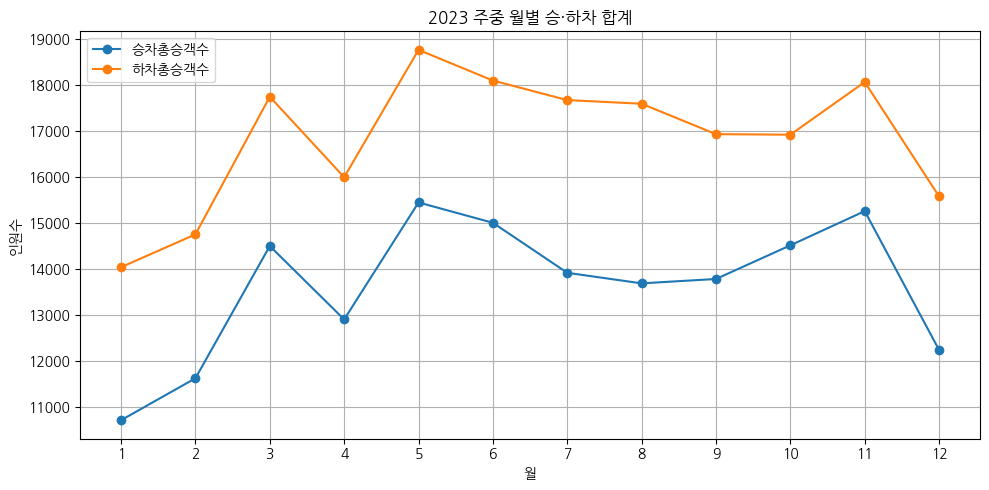

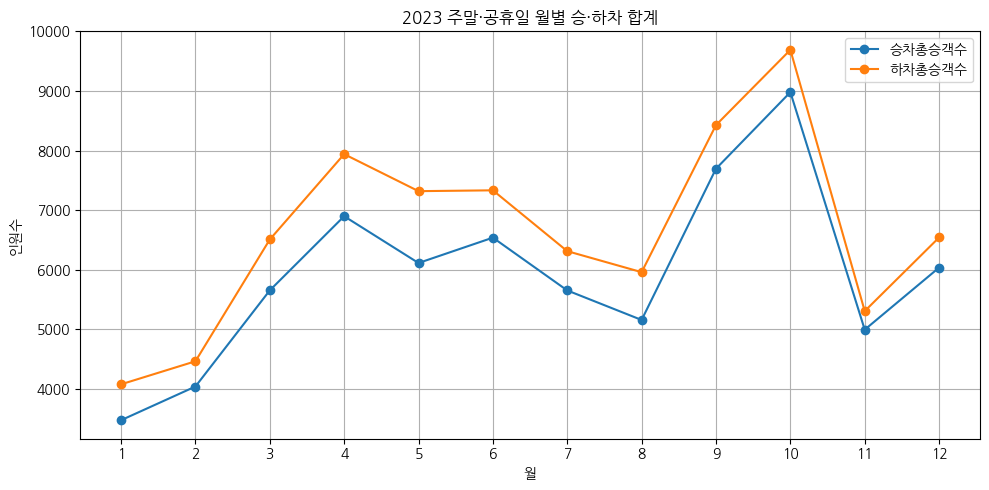

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _prep_month(df):
    d = df.copy()
    d['해당_월'] = pd.to_numeric(d['해당_월'], errors='coerce').astype('Int64')
    for c in ['승차총승객수','하차총승객수']:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
    # 월 1~12 모두 갖추기 (누락은 0으로)
    d = (d.set_index('해당_월')
          .reindex(range(1,13))
          .fillna(0)
          .rename_axis('해당_월')
          .reset_index())
    return d

def plot_month_lines(df, title):
    d = _prep_month(df)
    plt.figure(figsize=(10,5))
    plt.plot(d['해당_월'], d['승차총승객수'], marker='o', label='승차총승객수')
    plt.plot(d['해당_월'], d['하차총승객수'], marker='o', label='하차총승객수')
    plt.title(title)
    plt.xlabel('월'); plt.ylabel('인원수')
    plt.xticks(range(1,13))
    plt.grid(True); plt.legend()
    plt.tight_layout()
    plt.show()

# 사용 예시
plot_month_lines(grp_2023_week, '2023 주중 월별 승·하차 합계')
plot_month_lines(grp_2023_holi, '2023 주말·공휴일 월별 승·하차 합계')


In [174]:
잠원_holi_2023 = 잠원_holi[잠원_holi['년도'] == 2023]
잠원_holi_2024 = 잠원_holi[잠원_holi['년도'] == 2024]
잠원_week_2023 = 잠원_week[잠원_week['년도'] == 2023]
잠원_week_2024 = 잠원_week[잠원_week['년도'] == 2024]

In [175]:
잠원_holi_2023.head()

,지구별,주차장명,주차대수,이용시간,날짜,평균이용시간,년도,월,일,공휴일여부
730,PLT-010,잠원2-6주차장,1701,128848,2023-12-31,75.7483833,2023,12,31,쉬는날
731,PLT-010,잠원1주차장,289,18660,2023-12-31,64.5674740,2023,12,31,쉬는날
732,PLT-010,잠원2-6주차장,1260,100745,2023-12-30,79.9563492,2023,12,30,쉬는날
733,PLT-010,잠원1주차장,284,16205,2023-12-30,57.0598592,2023,12,30,쉬는날
742,PLT-010,잠원1주차장,319,20067,2023-12-25,62.9059561,2023,12,25,쉬는날


In [178]:
잠원_holi_2023_1 = 잠원_holi_2023[잠원_holi_2023['주차장명'].str.contains("1")]
잠원_holi_2023_2to6 = 잠원_holi_2023[잠원_holi_2023['주차장명'].str.contains("2")]
잠원_week_2023_1 = 잠원_week_2023[잠원_week_2023['주차장명'].str.contains("1")]
잠원_week_2023_2to6 = 잠원_week_2023[잠원_week_2023['주차장명'].str.contains("2")]

In [179]:
잠원_holi_2024_1 = 잠원_holi_2024[잠원_holi_2024['주차장명'].str.contains("1")]
잠원_holi_2024_2to6 = 잠원_holi_2024[잠원_holi_2024['주차장명'].str.contains("2")]
잠원_week_2024_1 = 잠원_week_2024[잠원_week_2024['주차장명'].str.contains("1")]
잠원_week_2024_2to6 = 잠원_week_2024[잠원_week_2024['주차장명'].str.contains("2")]

In [180]:
잠원_holi_2023_2to6.head()

,지구별,주차장명,주차대수,이용시간,날짜,평균이용시간,년도,월,일,공휴일여부
730,PLT-010,잠원2-6주차장,1701,128848,2023-12-31,75.7483833,2023,12,31,쉬는날
732,PLT-010,잠원2-6주차장,1260,100745,2023-12-30,79.9563492,2023,12,30,쉬는날
743,PLT-010,잠원2-6주차장,1946,168186,2023-12-25,86.4265159,2023,12,25,쉬는날
745,PLT-010,잠원2-6주차장,1811,156496,2023-12-24,86.4141358,2023,12,24,쉬는날
746,PLT-010,잠원2-6주차장,1299,101454,2023-12-23,78.1016166,2023,12,23,쉬는날


In [ ]:
grp_2023_holi = bus_2023_holi.groupby(["해당_월"])[['승차총승객수','하차총승객수']].sum().reset_index()
grp_2023_week = bus_2023_week.groupby(["해당_월"])[['승차총승객수','하차총승객수']].sum().reset_index()

In [184]:
grp2_6_2023_holi = 잠원_holi_2023_2to6.groupby(['월'])['주차대수'].sum().reset_index()
grp2_6_2023_week = 잠원_week_2023_2to6.groupby(['월'])['주차대수'].sum().reset_index()

In [186]:
grp2_6_2023_holi

,월,주차대수
0,1,18661
1,2,16964
2,3,21985
3,4,29110
4,5,26740
5,6,22941
6,7,20747
7,8,25426
8,9,32784
9,10,34844


In [187]:
grp_2023_holi = bus_2023_holi.groupby(["해당_월"])[['승차총승객수','하차총승객수']].sum().reset_index()

In [188]:
grp_2023_holi

,해당_월,승차총승객수,하차총승객수
0,1,3469,4072
1,2,4035,4459
2,3,5650,6505
3,4,6896,7939
4,5,6110,7317
5,6,6536,7331
6,7,5649,6309
7,8,5153,5956
8,9,7694,8427
9,10,8980,9691


피어슨 r(주차↔승차): 0.806
피어슨 r(주차↔하차): 0.849
스피어만 ρ(주차↔승차): 0.790
스피어만 ρ(주차↔하차): 0.790


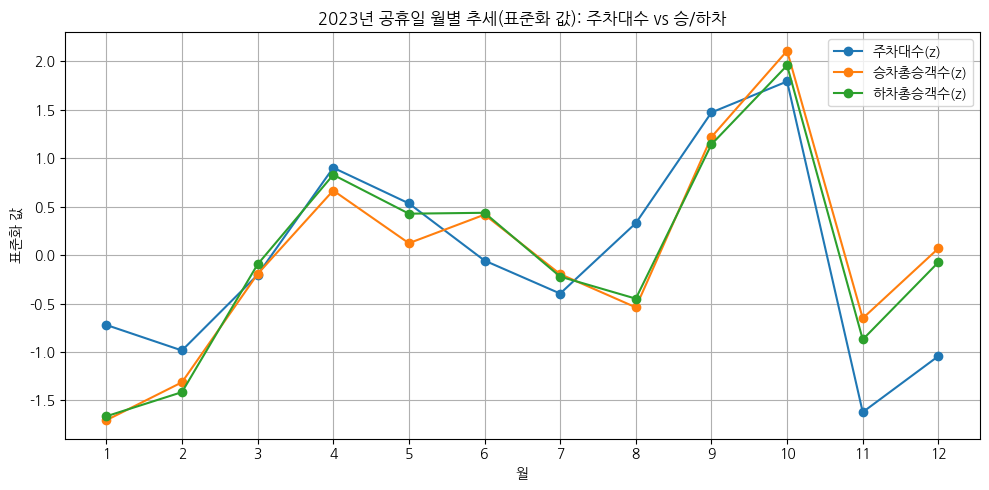

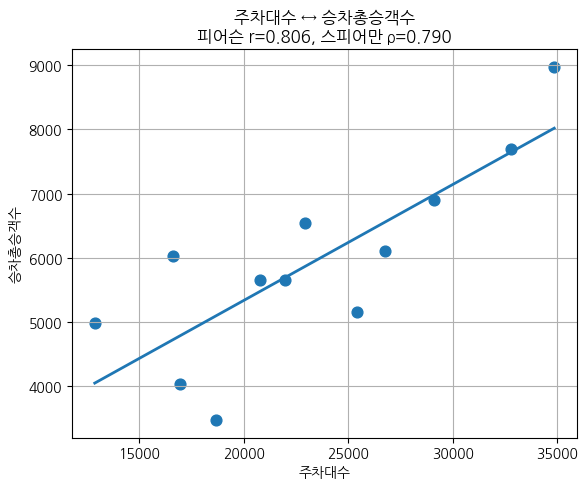

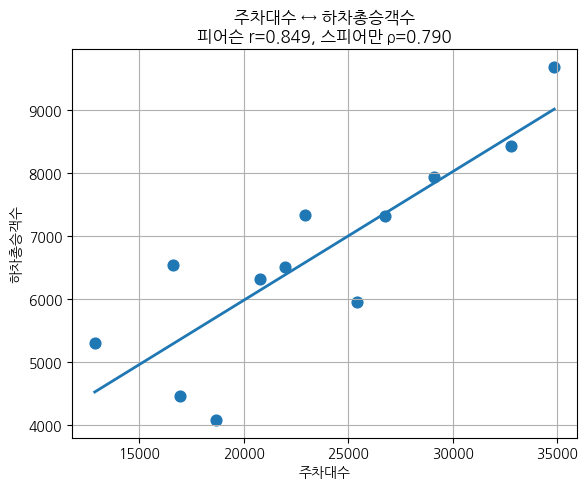

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) 원본 복사 & 컬럼 정리
a = grp2_6_2023_holi.rename(columns={'월':'해당_월'}).copy()         # [해당_월, 주차대수]
b = grp_2023_holi[['해당_월','승차총승객수','하차총승객수']].copy()  # [해당_월, 승차총승객수, 하차총승객수]

# 1) 숫자형 보정
a['해당_월'] = pd.to_numeric(a['해당_월'], errors='coerce')
a['주차대수'] = pd.to_numeric(a['주차대수'], errors='coerce')
b['해당_월'] = pd.to_numeric(b['해당_월'], errors='coerce')
b['승차총승객수'] = pd.to_numeric(b['승차총승객수'], errors='coerce')
b['하차총승객수'] = pd.to_numeric(b['하차총승객수'], errors='coerce')

# 2) 1~12월 프레임으로 정렬/누락월 채움(값은 NaN 유지)
months = pd.DataFrame({'해당_월': range(1, 13)})
a = months.merge(a, on='해당_월', how='left')
b = months.merge(b, on='해당_월', how='left')

# 3) 병합
df = a.merge(b, on='해당_월', how='inner')  # [해당_월, 주차대수, 승차총승객수, 하차총승객수]

# 4) 상관계수 (NaN 제외 후 계산)
pearson_board   = df['주차대수'].corr(df['승차총승객수'])
pearson_alight  = df['주차대수'].corr(df['하차총승객수'])
spearman_board  = df['주차대수'].corr(df['승차총승객수'], method='spearman')
spearman_alight = df['주차대수'].corr(df['하차총승객수'], method='spearman')
print(f"피어슨 r(주차↔승차): {pearson_board:.3f}")
print(f"피어슨 r(주차↔하차): {pearson_alight:.3f}")
print(f"스피어만 ρ(주차↔승차): {spearman_board:.3f}")
print(f"스피어만 ρ(주차↔하차): {spearman_alight:.3f}")

# 5) 추세 라인 그래프(스케일 차이를 줄이기 위해 z-정규화)
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

plt.figure(figsize=(10,5))
plt.plot(df['해당_월'], zscore(df['주차대수']), marker='o', label='주차대수(z)')
plt.plot(df['해당_월'], zscore(df['승차총승객수']), marker='o', label='승차총승객수(z)')
plt.plot(df['해당_월'], zscore(df['하차총승객수']), marker='o', label='하차총승객수(z)')
plt.title('2023년 공휴일 월별 추세(표준화 값): 주차대수 vs 승/하차')
plt.xlabel('월'); plt.ylabel('표준화 값')
plt.xticks(range(1,13))
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

# 6) 산점도 + 단순 회귀선 (주차대수 ↔ 승차/하차)
for target_col, title in [('승차총승객수','주차대수 ↔ 승차총승객수'),
                          ('하차총승객수','주차대수 ↔ 하차총승객수')]:
    m = df[['주차대수', target_col]].dropna()
    x, y = m['주차대수'], m[target_col]

    plt.figure(figsize=(6,5))
    plt.scatter(x, y, s=60)
    if len(m) >= 2:
        k, b0 = np.polyfit(x, y, 1)                 # y = kx + b0
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, k*xs + b0, linewidth=2)

    r_p = x.corr(y)
    r_s = x.corr(y, method='spearman')
    plt.title(f"{title}\n피어슨 r={r_p:.3f}, 스피어만 ρ={r_s:.3f}")
    plt.xlabel('주차대수'); plt.ylabel(target_col)
    plt.grid(True); plt.tight_layout(); plt.show()


피어슨 r(주차↔승차): 0.749
피어슨 r(주차↔하차): 0.821
스피어만 ρ(주차↔승차): 0.678
스피어만 ρ(주차↔하차): 0.790


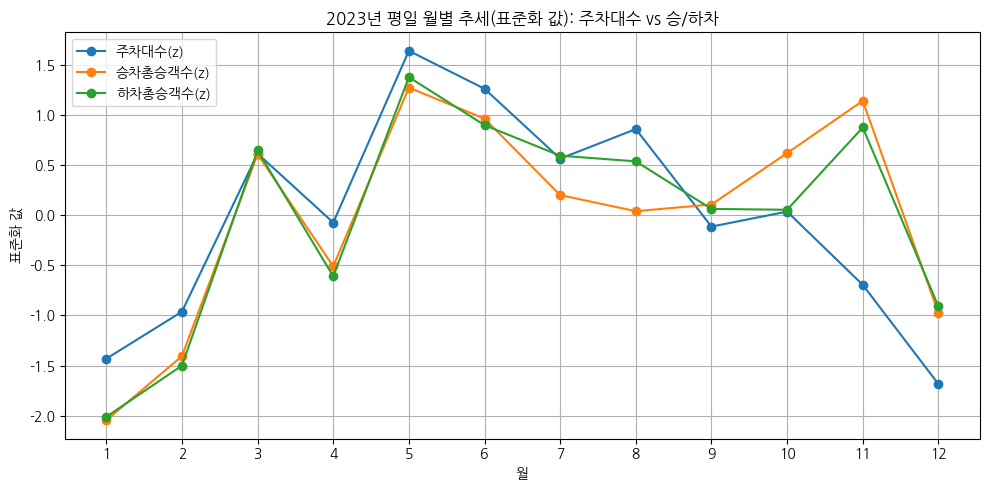

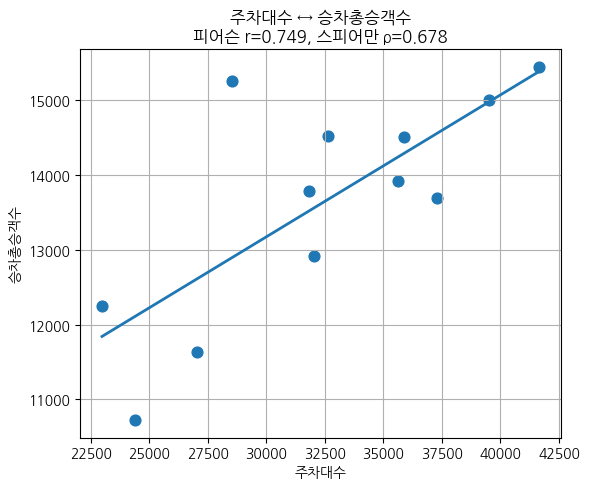

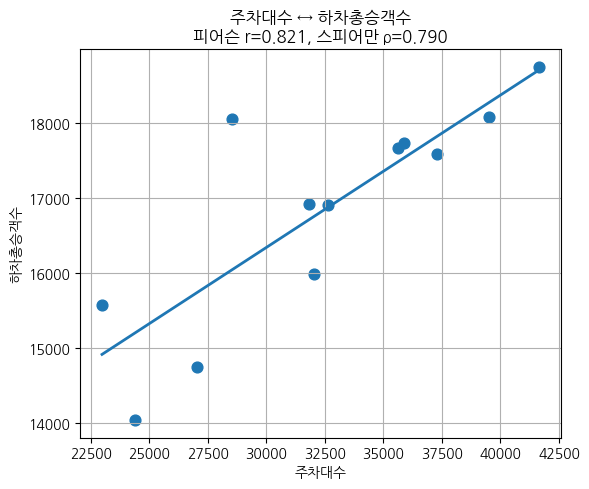

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) 원본 복사 & 컬럼 정리
a = grp2_6_2023_week.rename(columns={'월':'해당_월'}).copy()         # [해당_월, 주차대수]
b = grp_2023_week[['해당_월','승차총승객수','하차총승객수']].copy()  # [해당_월, 승차총승객수, 하차총승객수]

# 1) 숫자형 보정
a['해당_월'] = pd.to_numeric(a['해당_월'], errors='coerce')
a['주차대수'] = pd.to_numeric(a['주차대수'], errors='coerce')
b['해당_월'] = pd.to_numeric(b['해당_월'], errors='coerce')
b['승차총승객수'] = pd.to_numeric(b['승차총승객수'], errors='coerce')
b['하차총승객수'] = pd.to_numeric(b['하차총승객수'], errors='coerce')

# 2) 1~12월 프레임으로 정렬/누락월 채움(값은 NaN 유지)
months = pd.DataFrame({'해당_월': range(1, 13)})
a = months.merge(a, on='해당_월', how='left')
b = months.merge(b, on='해당_월', how='left')

# 3) 병합
df = a.merge(b, on='해당_월', how='inner')  # [해당_월, 주차대수, 승차총승객수, 하차총승객수]

# 4) 상관계수 (NaN 제외 후 계산)
pearson_board   = df['주차대수'].corr(df['승차총승객수'])
pearson_alight  = df['주차대수'].corr(df['하차총승객수'])
spearman_board  = df['주차대수'].corr(df['승차총승객수'], method='spearman')
spearman_alight = df['주차대수'].corr(df['하차총승객수'], method='spearman')
print(f"피어슨 r(주차↔승차): {pearson_board:.3f}")
print(f"피어슨 r(주차↔하차): {pearson_alight:.3f}")
print(f"스피어만 ρ(주차↔승차): {spearman_board:.3f}")
print(f"스피어만 ρ(주차↔하차): {spearman_alight:.3f}")

# 5) 추세 라인 그래프(스케일 차이를 줄이기 위해 z-정규화)
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

plt.figure(figsize=(10,5))
plt.plot(df['해당_월'], zscore(df['주차대수']), marker='o', label='주차대수(z)')
plt.plot(df['해당_월'], zscore(df['승차총승객수']), marker='o', label='승차총승객수(z)')
plt.plot(df['해당_월'], zscore(df['하차총승객수']), marker='o', label='하차총승객수(z)')
plt.title('2023년 평일 월별 추세(표준화 값): 주차대수 vs 승/하차')
plt.xlabel('월'); plt.ylabel('표준화 값')
plt.xticks(range(1,13))
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

# 6) 산점도 + 단순 회귀선 (주차대수 ↔ 승차/하차)
for target_col, title in [('승차총승객수','주차대수 ↔ 승차총승객수'),
                          ('하차총승객수','주차대수 ↔ 하차총승객수')]:
    m = df[['주차대수', target_col]].dropna()
    x, y = m['주차대수'], m[target_col]

    plt.figure(figsize=(6,5))
    plt.scatter(x, y, s=60)
    if len(m) >= 2:
        k, b0 = np.polyfit(x, y, 1)                 # y = kx + b0
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, k*xs + b0, linewidth=2)

    r_p = x.corr(y)
    r_s = x.corr(y, method='spearman')
    plt.title(f"{title}\n피어슨 r={r_p:.3f}, 스피어만 ρ={r_s:.3f}")
    plt.xlabel('주차대수'); plt.ylabel(target_col)
    plt.grid(True); plt.tight_layout(); plt.show()


In [194]:
traffic_2024_1to4 = pd.read_csv('../Data/2024_1to4.csv')

In [195]:
traffic_2024_1to4.head()

,Unnamed: 0,해당일,시간대,압구정로11길,잠원로상단,잠원로하단
0,0,20240101,0,21.0000000,29.0000000,29.8333333
1,1,20240101,1,21.0000000,31.1250000,23.8750000
2,2,20240101,2,21.0000000,34.6250000,22.5000000
3,3,20240101,3,21.0000000,31.5000000,21.6250000
4,4,20240101,4,21.0000000,29.2500000,25.8750000


In [196]:
del traffic_2024_1to4['Unnamed: 0']

In [200]:
traffic_2024_1to4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   해당일      1829 non-null   int64  
 1   시간대      1829 non-null   int64  
 2   압구정로11길  1829 non-null   float64
 3   잠원로상단    1829 non-null   float64
 4   잠원로하단    1829 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 71.6 KB


In [198]:
traffic_2024_1to4.해당일.unique()

array([20240101, 20240102, 20240103, 20240104, 20240105, 20240106,
       20240107, 20240108, 20240109, 20240110, 20240111, 20240112,
       20240113, 20240114, 20240115, 20240116, 20240117, 20240118,
       20240119, 20240120, 20240121, 20240122, 20240123, 20240124,
       20240125, 20240126, 20240127, 20240128, 20240129, 20240130,
       20240131, 20240201, 20240202, 20240203, 20240204, 20240205,
       20240206, 20240207, 20240208, 20240209, 20240210, 20240211,
       20240212, 20240213, 20240214, 20240215, 20240216, 20240217,
       20240218, 20240219, 20240220, 20240221, 20240222, 20240223,
       20240224, 20240225, 20240226, 20240227, 20240228, 20240229,
       20240301, 20240302, 20240303, 20240304, 20240305, 20240306,
       20240307, 20240308, 20240309, 20240310, 20240311, 20240312,
       20240313, 20240314, 20240315, 20240316, 20240317])